In [1]:
import os
import logging
import pandas as pd 
import numpy as np 

from pymongo import MongoClient 
from dotenv import load_dotenv

logging.basicConfig(
    level = logging.INFO,
    format = "%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)

logger = logging.getLogger(__name__)

load_dotenv()
MONGO_URI = os.getenv("MONGO_URI")

logger.info("Environment loaded. Libraries ready.")
logger.debug("MONGO_URI resolved: %s", "OK" if MONGO_URI else "MISSING")

2026-06-06 10:48:59  INFO      Environment loaded. Libraries ready.


In [2]:
# Fetching from MongoDB
logging.getLogger("pymongo").setLevel(logging.WARNING)
logger.info("Connecting to MongoDB Atlas ...")

client = MongoClient(MONGO_URI, serverSelectionTimeoutMS = 15000)
collection = client["aqi_project"]["features"]

logger.info("Fetching all the documents.")

cursor = collection.find({}, {"_id": 0})
df = pd.DataFrame(list(cursor))

logger.info("Fetch complete — %d rows × %d columns", len(df), len(df.columns))


2026-06-06 10:49:02  INFO      Connecting to MongoDB Atlas ...
2026-06-06 10:49:03  INFO      Fetching all the documents.
2026-06-06 10:49:08  INFO      Fetch complete — 17640 rows × 23 columns


In [3]:
# Parsing timestamp and sorting
logger.info("Parsing timestamp and sorting chronologically ...")

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop = True)

date_min = df["timestamp"].min()
date_max = df["timestamp"].max()
span_days = (date_max - date_min).days

logger.info("Date range: %s → %s", date_min.date(), date_max.date())
logger.info("Total span: %d days (~%.1f years)", span_days, span_days / 365)
logger.debug("Index reset after sort — first timestamp: %s", df["timestamp"].iloc[0])

2026-06-06 10:49:12  INFO      Parsing timestamp and sorting chronologically ...
2026-06-06 10:49:13  INFO      Date range: 2024-06-01 → 2026-06-05
2026-06-06 10:49:13  INFO      Total span: 734 days (~2.0 years)


In [4]:
# Structural health check:
logger.info("Running structural health check...")
logger.info("Shape — rows: %d  columns: %d", df.shape[0], df.shape[1])

for col, dtype in df.dtypes.items():
    logger.debug("Column %-30s dtype: %s", col, dtype)

null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0]

if null_counts.empty:
    logger.info("Null check passed — no nulls detected.")
else:
    logger.warning("Nulls detected in %d column(s):", len(null_counts))
    for col, count in null_counts.items():
        logger.warning("  %-30s %d nulls", col, count)


2026-06-06 10:49:17  INFO      Running structural health check...
2026-06-06 10:49:17  INFO      Shape — rows: 17640  columns: 23
2026-06-06 10:49:17  INFO      Null check passed — no nulls detected.


In [5]:
# Descriptive Statistics
logger.info("Generating descriptive statistics...")
pd.set_option("display.float_format", "{:.2f}".format)
df.describe()

2026-06-06 10:49:22  INFO      Generating descriptive statistics...


,aqi,pm2_5,pm10,no2,o3,co,so2,temp,humidity,pressure,wind_speed,wind_deg,clouds,hour,day_of_week,month,is_weekend,aqi_change_rate,pm2_5_rolling_3h
count,17640.00,17640.00,17640.00,17640.00,17640.00,17640.00,17640.00,17640.00,17640.00,17640.00,17640.00,17640.00,17640.00,17640.00,17640.00,17640.00,17640.00,17640.00,17640.00
mean,89.49,28.34,59.08,20.30,71.53,507.58,14.13,26.76,64.94,1007.40,12.12,219.34,32.21,11.50,3.00,6.52,0.29,0.06,28.32
std,29.19,12.77,37.04,18.49,39.37,446.78,8.60,4.79,21.34,6.95,6.06,91.07,39.63,6.92,2.00,3.44,0.45,9.41,12.50
min,22.00,3.50,3.70,0.00,0.00,46.00,2.60,9.20,5.00,990.10,0.00,1.00,0.00,0.00,0.00,1.00,0.00,-254.00,3.90
25%,68.00,19.60,36.20,7.50,44.00,223.00,7.80,24.00,51.00,1002.00,7.80,211.00,0.00,5.75,1.00,4.00,0.00,-3.00,19.67
50%,82.00,25.30,49.90,13.70,63.00,335.00,12.50,27.60,70.00,1007.60,11.10,248.00,9.00,11.50,3.00,7.00,0.00,0.00,25.40
75%,104.00,33.90,71.20,26.70,95.00,634.00,18.10,30.00,82.00,1013.20,15.30,271.00,70.00,17.25,5.00,10.00,1.00,3.00,33.83
max,400.00,108.70,504.80,138.50,228.00,4515.00,65.40,41.20,100.00,1024.20,46.60,360.00,100.00,23.00,6.00,12.00,1.00,140.00,97.70


In [6]:
#=====================================================================
# ------------------ AQI Distribution Analysis ------------------
#=====================================================================

# AQI Category definations
logger.info("Defining AQI category bins and EPA colour palette...")

AQI_BINS   = [0, 50, 100, 150, 200, 300, 500]
AQI_LABELS = ["Good", "Moderate", "USG", "Unhealthy", "Very Unhealthy", "Hazardous"]
AQI_COLORS = {
    "Good"           : "#00e400",
    "Moderate"       : "#ffff00",
    "USG"            : "#ff7e00",
    "Unhealthy"      : "#ff0000",
    "Very Unhealthy" : "#8f3f97",
    "Hazardous"      : "#7e0023",
}

df["aqi_category"] = pd.cut(
    df["aqi"],
    bins=AQI_BINS,
    labels=AQI_LABELS,
    right=True
)

category_counts = df["aqi_category"].value_counts().reindex(AQI_LABELS)
logger.info("AQI category distribution:")
for cat, count in category_counts.items():
    pct = count / len(df) * 100
    logger.info("  %-22s %5d rows  (%4.1f%%)", cat, count, pct)

2026-06-06 10:49:28  INFO      Defining AQI category bins and EPA colour palette...
2026-06-06 10:49:28  INFO      AQI category distribution:
2026-06-06 10:49:28  INFO        Good                     389 rows  ( 2.2%)
2026-06-06 10:49:28  INFO        Moderate               12380 rows  (70.2%)
2026-06-06 10:49:28  INFO        USG                     3844 rows  (21.8%)
2026-06-06 10:49:28  INFO        Unhealthy               1007 rows  ( 5.7%)
2026-06-06 10:49:28  INFO        Very Unhealthy            16 rows  ( 0.1%)
2026-06-06 10:49:28  INFO        Hazardous                  4 rows  ( 0.0%)


2026-06-06 10:49:43  INFO      Rendering Section 2 — AQI Distribution 2×2 panel...
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7388\3985670352.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(monthly_groups, labels=month_labels, patch_artist=True,
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7388\3985670352.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax4.boxplot(hourly_groups, labels=range(24), patch_artist=True,
2026-06-06 10:49:44  INFO      Section 2 panel saved → reports/figures/section2_aqi_distribution.png


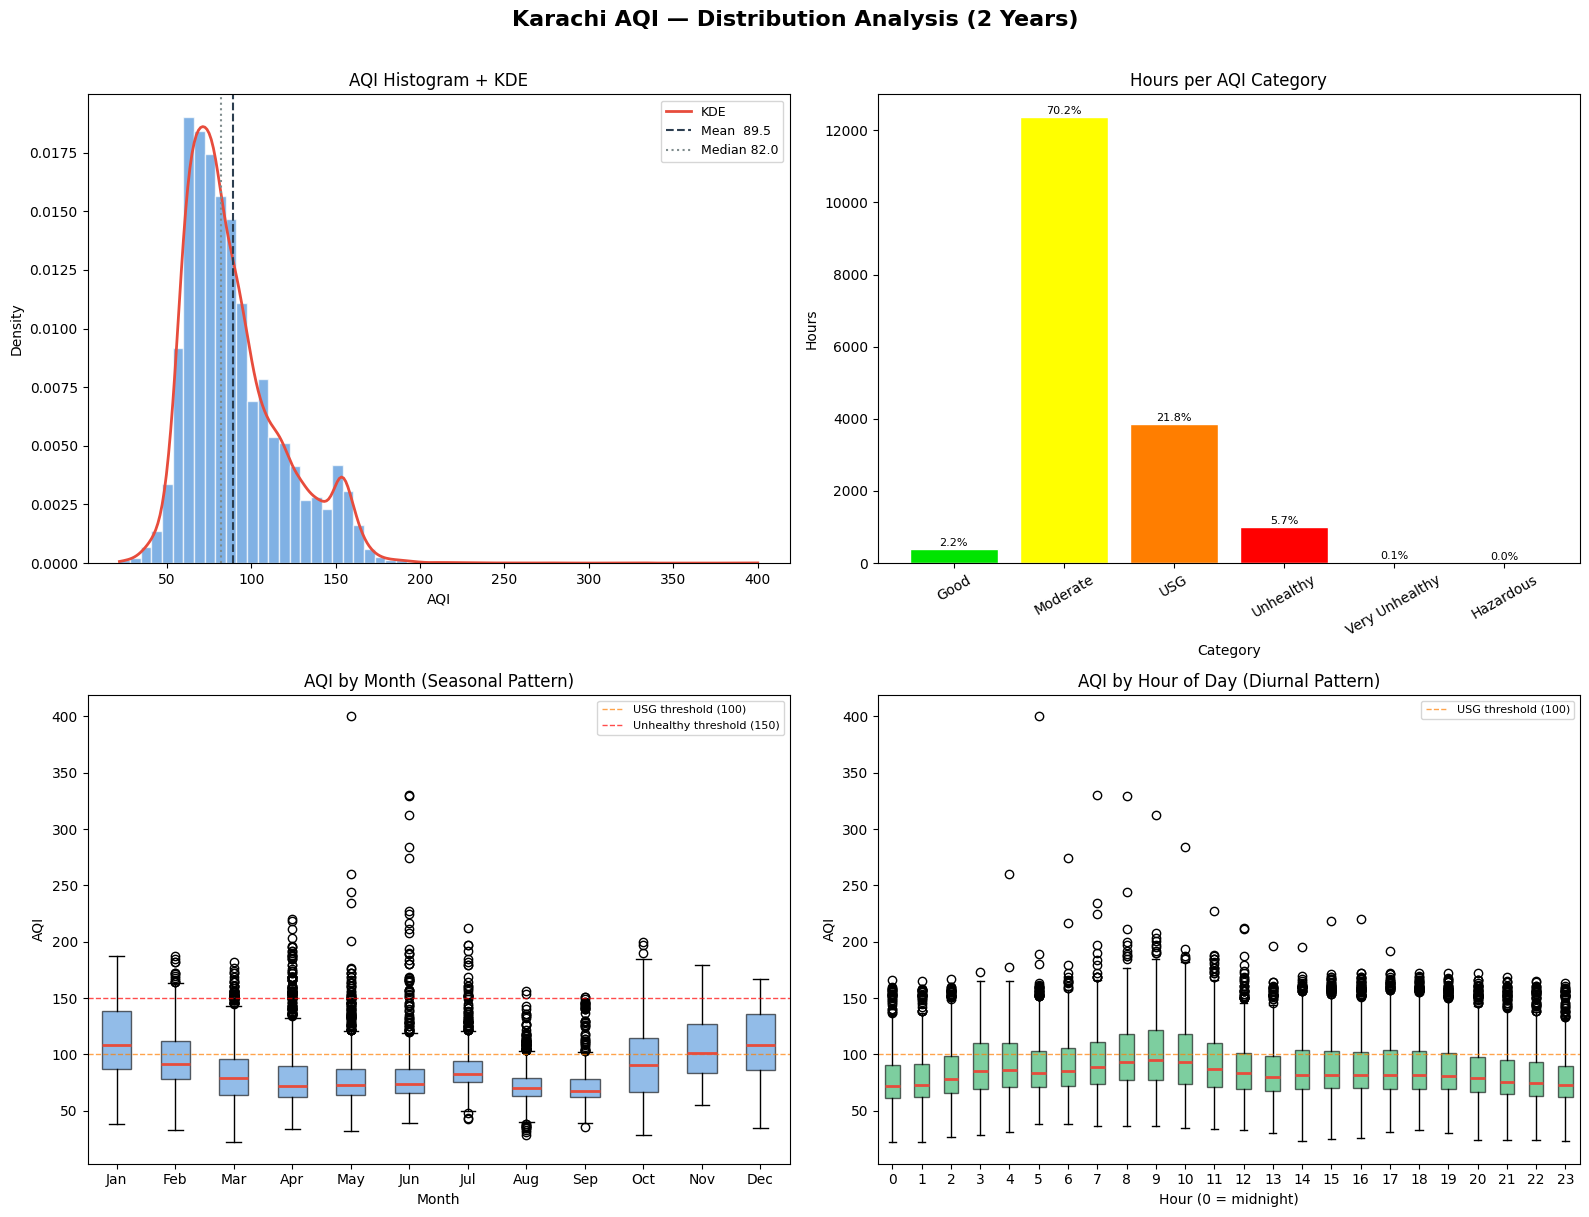

In [7]:
# AQI Distribution panel

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde

logger.info("Rendering Section 2 — AQI Distribution 2×2 panel...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Karachi AQI — Distribution Analysis (2 Years)", fontsize=16, fontweight="bold", y=1.01)

# Plot 1: Histogram & KDE
ax1 = axes[0, 0]
ax1.hist(df["aqi"], bins=60, color="#4a90d9", edgecolor="white", alpha=0.7, density=True)
kde_x = np.linspace(df["aqi"].min(), df["aqi"].max(), 300)
kde_y = gaussian_kde(df["aqi"])(kde_x)
ax1.plot(kde_x, kde_y, color="#e74c3c", linewidth=2, label="KDE")
ax1.axvline(df["aqi"].mean(),   color="#2c3e50", linestyle="--", linewidth=1.5, label=f"Mean  {df['aqi'].mean():.1f}")
ax1.axvline(df["aqi"].median(), color="#7f8c8d", linestyle=":",  linewidth=1.5, label=f"Median {df['aqi'].median():.1f}")
ax1.set_title("AQI Histogram + KDE")
ax1.set_xlabel("AQI")
ax1.set_ylabel("Density")
ax1.legend(fontsize=9)

logger.debug("Plot 1 (Histogram + KDE) rendered.")

# Plot 2: Category Bar Chart
ax2 = axes[0, 1]
bar_colors = [AQI_COLORS[cat] for cat in AQI_LABELS]
bars = ax2.bar(AQI_LABELS, category_counts.values, color=bar_colors, edgecolor="white")
ax2.set_title("Hours per AQI Category")
ax2.set_xlabel("Category")
ax2.set_ylabel("Hours")
ax2.tick_params(axis="x", rotation=30)

for bar, count in zip(bars, category_counts.values):
    pct = count / len(df) * 100
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)

logger.debug("Plot 2 (Category bar chart) rendered.")

# Plot 3: Monthly plot box
ax3 = axes[1, 0]
monthly_groups = [df[df["month"] == m]["aqi"].values for m in range(1, 13)]
month_labels   = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
bp = ax3.boxplot(monthly_groups, labels=month_labels, patch_artist=True,
                medianprops={"color": "#e74c3c", "linewidth": 2})

for patch in bp["boxes"]:
    patch.set_facecolor("#4a90d9")
    patch.set_alpha(0.6)

ax3.set_title("AQI by Month (Seasonal Pattern)")
ax3.set_xlabel("Month")
ax3.set_ylabel("AQI")
ax3.axhline(100, color="#ff7e00", linestyle="--", linewidth=1, alpha=0.7, label="USG threshold (100)")
ax3.axhline(150, color="#ff0000", linestyle="--", linewidth=1, alpha=0.7, label="Unhealthy threshold (150)")
ax3.legend(fontsize=8)

logger.debug("Plot 3 (Monthly box plot) rendered.")

# Plot 4: Hour-of-day Box plot
ax4 = axes[1, 1]
hourly_groups = [df[df["hour"] == h]["aqi"].values for h in range(24)]
bp2 = ax4.boxplot(hourly_groups, labels=range(24), patch_artist=True,
                medianprops={"color": "#e74c3c", "linewidth": 2})
for patch in bp2["boxes"]:
    patch.set_facecolor("#27ae60")
    patch.set_alpha(0.6)
ax4.set_title("AQI by Hour of Day (Diurnal Pattern)")
ax4.set_xlabel("Hour (0 = midnight)")
ax4.set_ylabel("AQI")
ax4.axhline(100, color="#ff7e00", linestyle="--", linewidth=1, alpha=0.7, label="USG threshold (100)")
ax4.legend(fontsize=8)
logger.debug("Plot 4 (Hourly box plot) rendered.")

plt.tight_layout()
plt.savefig("../reports/figures/section2_aqi_distribution.png", dpi=150, bbox_inches="tight")
logger.info("Section 2 panel saved → reports/figures/section2_aqi_distribution.png")
plt.show()


In [9]:
# AQI Distribution Analysis Summary

logger.info("AQI Distribution Analysis Summary ...")
logger.info("Skewness of AQI distribution : %.3f", df["aqi"].skew())
logger.info("Kurtosis of AQI distribution : %.3f", df["aqi"].kurt())
logger.info("Hours above USG  threshold (>100) : %d  (%.1f%%)",
            (df["aqi"] > 100).sum(), (df["aqi"] > 100).mean() * 100)
logger.info("Hours above Unhealthy threshold (>150) : %d  (%.1f%%)",
            (df["aqi"] > 150).sum(), (df["aqi"] > 150).mean() * 100)
logger.info("Section 2 complete.")

2026-06-06 10:49:57  INFO      AQI Distribution Analysis Summary ...
2026-06-06 10:49:57  INFO      Skewness of AQI distribution : 1.146
2026-06-06 10:49:57  INFO      Kurtosis of AQI distribution : 2.099
2026-06-06 10:49:57  INFO      Hours above USG  threshold (>100) : 4871  (27.6%)
2026-06-06 10:49:57  INFO      Hours above Unhealthy threshold (>150) : 1027  (5.8%)
2026-06-06 10:49:57  INFO      Section 2 complete.


In [10]:
#=====================================================================
# ----------------- Pollutatns Correlation Analysis ------------------
#=====================================================================

# Defininf pollutants and weather feature cols

logger.info("Defining pollutant and weather feature columns for correlation analysis...")

POLLUTANT_COLS = ["pm2_5", "pm10", "no2", "o3", "co", "so2"]
WEATHER_COLS = ["temp", "humidity", "pressure", "wind_speed", "wind_deg", "clouds"]
ANALYSIS_COLS = POLLUTANT_COLS + WEATHER_COLS + ["aqi"]

df_corr = df[ANALYSIS_COLS].copy()

logger.info("Analysis columns selected: %d total", len(ANALYSIS_COLS))
logger.debug("Pollutants : %s", POLLUTANT_COLS)
logger.debug("Weather    : %s", WEATHER_COLS)

2026-06-06 10:50:00  INFO      Defining pollutant and weather feature columns for correlation analysis...
2026-06-06 10:50:00  INFO      Analysis columns selected: 13 total


2026-06-06 10:50:05  INFO      Rendering Section 3 — Pollutant Correlation Analysis panel...
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7388\2750968498.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_box.boxplot(
2026-06-06 10:50:09  INFO      Section 3 panel saved → reports/figures/section3_correlation_analysis.png


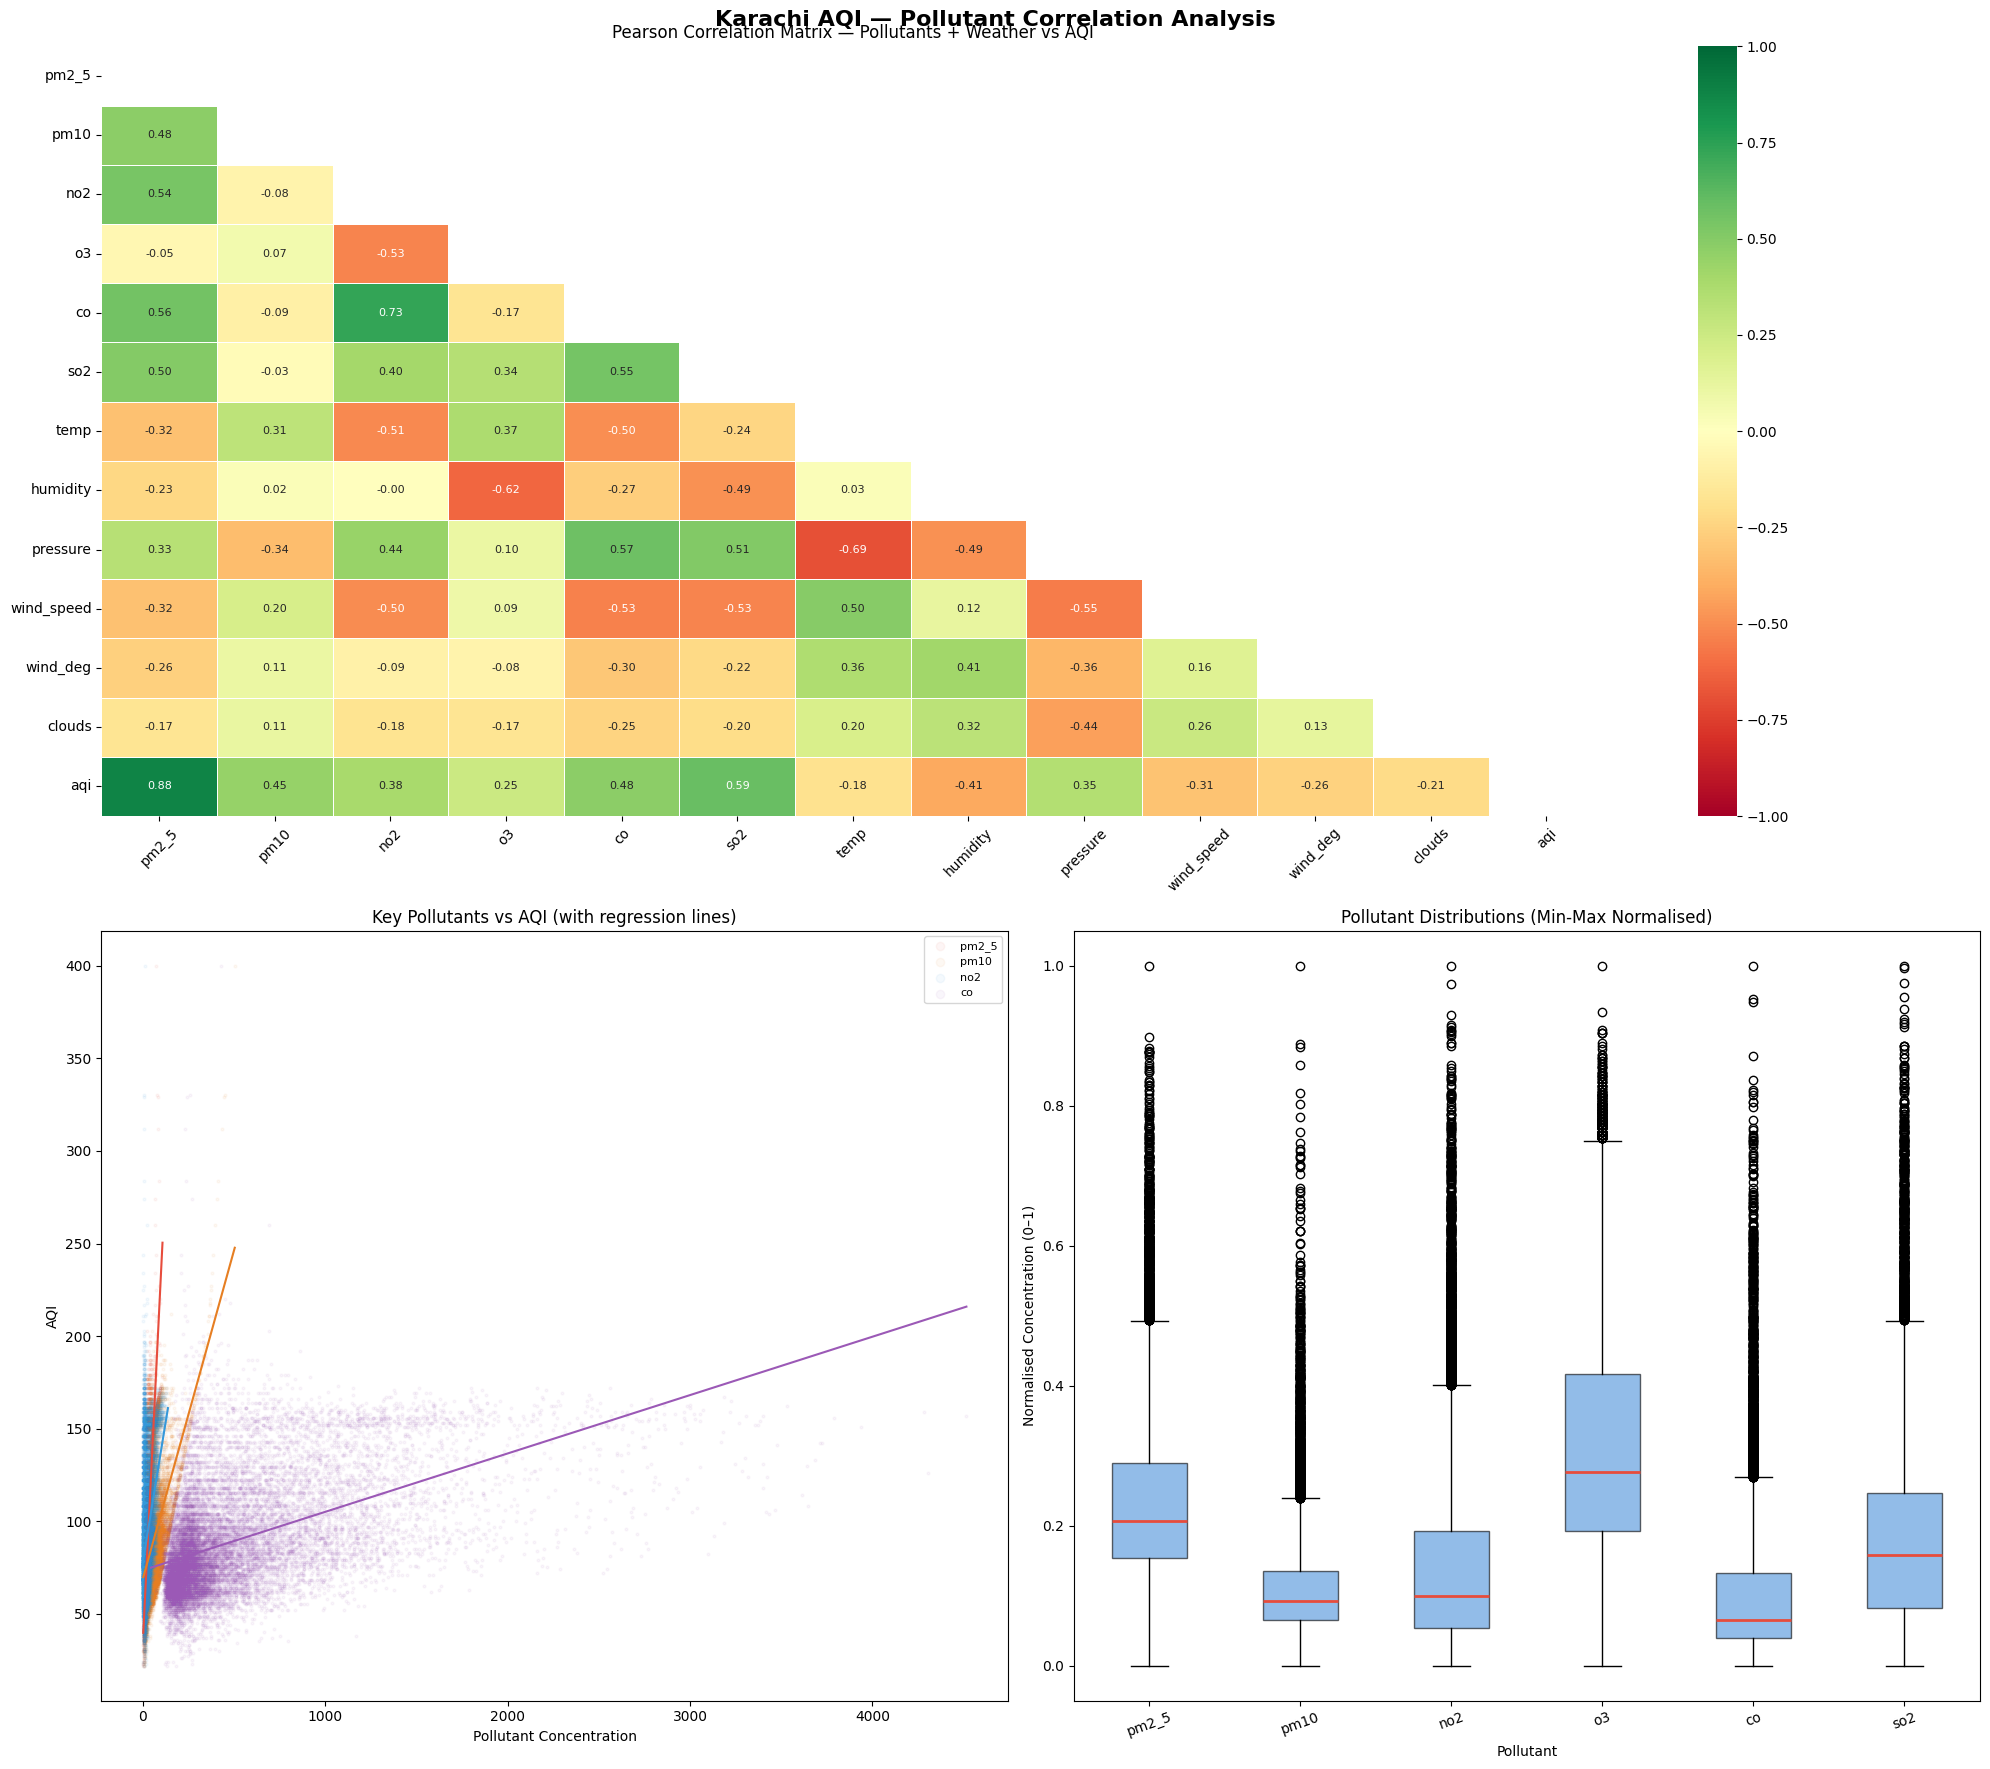

In [11]:
# Pollution Correlation Panel

import seaborn as sns

logger.info("Rendering Section 3 — Pollutant Correlation Analysis panel...")

fig = plt.figure(figsize=(20, 18))
fig.suptitle("Karachi AQI — Pollutant Correlation Analysis", fontsize=16, fontweight="bold")

# Layout: heatmap takes top half, scatter + box split the bottom half
ax_heat  = fig.add_subplot(2, 2, (1, 2))  
ax_scat  = fig.add_subplot(2, 2, 3)       
ax_box   = fig.add_subplot(2, 2, 4)       

# Plot 1: Correlation Heatmap
corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) 

sns.heatmap(
    corr_matrix,
    mask=mask,
    ax=ax_heat,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={"size": 8}
)
ax_heat.set_title("Pearson Correlation Matrix — Pollutants + Weather vs AQI", fontsize=12)
ax_heat.tick_params(axis="x", rotation=45)
ax_heat.tick_params(axis="y", rotation=0)
logger.debug("Plot 1 (Correlation heatmap) rendered.")

# Plot 2: Pollutants vs AQI Scatter
scatter_cols = ["pm2_5", "pm10", "no2", "co"]
colors = ["#e74c3c", "#e67e22", "#3498db", "#9b59b6"]

for col, color in zip(scatter_cols, colors):
    ax_scat.scatter(df_corr[col], df_corr["aqi"],
                    alpha=0.05, s=4, color=color, label=col)
    m, b = np.polyfit(df_corr[col], df_corr["aqi"], 1)
    x_line = np.linspace(df_corr[col].min(), df_corr[col].max(), 100)
    ax_scat.plot(x_line, m * x_line + b, color=color, linewidth=1.5)

ax_scat.set_title("Key Pollutants vs AQI (with regression lines)")
ax_scat.set_xlabel("Pollutant Concentration")
ax_scat.set_ylabel("AQI")
ax_scat.legend(fontsize=8, markerscale=3)
logger.debug("Plot 2 (Scatter + regression) rendered.")

# Pollutants Distribution Box
from sklearn.preprocessing import MinMaxScaler

scaler        = MinMaxScaler()
df_normalised = pd.DataFrame(
    scaler.fit_transform(df_corr[POLLUTANT_COLS]),
    columns=POLLUTANT_COLS
)

ax_box.boxplot(
    [df_normalised[col].values for col in POLLUTANT_COLS],
    labels=POLLUTANT_COLS,
    patch_artist=True,
    medianprops={"color": "#e74c3c", "linewidth": 2},
    boxprops={"facecolor": "#4a90d9", "alpha": 0.6}
)
ax_box.set_title("Pollutant Distributions (Min-Max Normalised)")
ax_box.set_xlabel("Pollutant")
ax_box.set_ylabel("Normalised Concentration (0–1)")
ax_box.tick_params(axis="x", rotation=20)
logger.debug("Plot 3 (Normalised box plot) rendered.")

plt.tight_layout()
plt.savefig("../reports/figures/section3_correlation_analysis.png", dpi=150, bbox_inches="tight")
logger.info("Section 3 panel saved → reports/figures/section3_correlation_analysis.png")
plt.show()

In [12]:
# Pollutatns Correlation Analysis Summary
logger.info("Pollutatns Correlation Analysis ...")

corr_with_aqi = corr_matrix["aqi"].drop("aqi").sort_values(ascending=False)
logger.info("Feature correlations with AQI (descending):")
for feat, val in corr_with_aqi.items():
    logger.info("  %-20s  r = %+.3f", feat, val)

top_feature = corr_with_aqi.index[0]
logger.info("Strongest AQI predictor (linear): %s  (r = %.3f)",
            top_feature, corr_with_aqi.iloc[0])
logger.info("Section 3 complete.")

2026-06-06 10:50:17  INFO      Pollutatns Correlation Analysis ...
2026-06-06 10:50:17  INFO      Feature correlations with AQI (descending):
2026-06-06 10:50:17  INFO        pm2_5                 r = +0.876
2026-06-06 10:50:17  INFO        so2                   r = +0.590
2026-06-06 10:50:17  INFO        co                    r = +0.483
2026-06-06 10:50:17  INFO        pm10                  r = +0.450
2026-06-06 10:50:17  INFO        no2                   r = +0.384
2026-06-06 10:50:17  INFO        pressure              r = +0.350
2026-06-06 10:50:17  INFO        o3                    r = +0.251
2026-06-06 10:50:17  INFO        temp                  r = -0.183
2026-06-06 10:50:17  INFO        clouds                r = -0.212
2026-06-06 10:50:17  INFO        wind_deg              r = -0.256
2026-06-06 10:50:17  INFO        wind_speed            r = -0.314
2026-06-06 10:50:17  INFO        humidity              r = -0.410
2026-06-06 10:50:17  INFO      Strongest AQI predictor (linear): p

In [13]:
#=====================================================================
# ----------------- Time Series Analysis ------------------
#=====================================================================

logger.info("Preparing time series data...")

# Rolling mean — 168 hours = 7 days
df["aqi_rolling_7d"] = df["aqi"].rolling(window=168, min_periods=1).mean()

# Year split for YoY comparison
df["year"] = df["timestamp"].dt.year
years      = sorted(df["year"].unique())

# Top 10 worst
top10 = (
    df[["timestamp", "aqi", "aqi_category"]]
    .nlargest(10, "aqi")
    .reset_index(drop=True)
)

logger.info("Rolling 7-day mean computed.")
logger.info("Years in dataset: %s", years)
logger.debug("7-day rolling mean range: %.1f → %.1f",
            df["aqi_rolling_7d"].min(), df["aqi_rolling_7d"].max())

logger.info("Top 10 worst AQI episodes:")
for _, row in top10.iterrows():
    logger.info("  %s   AQI: %d  (%s)",
                row["timestamp"].strftime("%Y-%m-%d %H:%M"),
                row["aqi"],
                row["aqi_category"])

2026-06-06 10:50:30  INFO      Preparing time series data...
2026-06-06 10:50:30  INFO      Rolling 7-day mean computed.
2026-06-06 10:50:30  INFO      Years in dataset: [np.int32(2024), np.int32(2025), np.int32(2026)]
2026-06-06 10:50:30  INFO      Top 10 worst AQI episodes:
2026-06-06 10:50:30  INFO        2026-05-04 05:00   AQI: 400  (Hazardous)
2026-06-06 10:50:30  INFO        2024-06-01 07:00   AQI: 330  (Hazardous)
2026-06-06 10:50:30  INFO        2024-06-01 08:00   AQI: 329  (Hazardous)
2026-06-06 10:50:30  INFO        2024-06-01 09:00   AQI: 312  (Hazardous)
2026-06-06 10:50:30  INFO        2024-06-01 10:00   AQI: 284  (Very Unhealthy)
2026-06-06 10:50:30  INFO        2024-06-01 06:00   AQI: 274  (Very Unhealthy)
2026-06-06 10:50:30  INFO        2026-05-04 04:00   AQI: 260  (Very Unhealthy)
2026-06-06 10:50:30  INFO        2025-05-31 08:00   AQI: 244  (Very Unhealthy)
2026-06-06 10:50:30  INFO        2025-05-31 07:00   AQI: 234  (Very Unhealthy)
2026-06-06 10:50:30  INFO       

2026-06-06 10:54:12  INFO      Rendering Time Series Analysis panel...
2026-06-06 10:54:12  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-06 10:54:12  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-06 10:54:12  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-06 10:54:12  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-06 10:54:12  INFO      Using categori

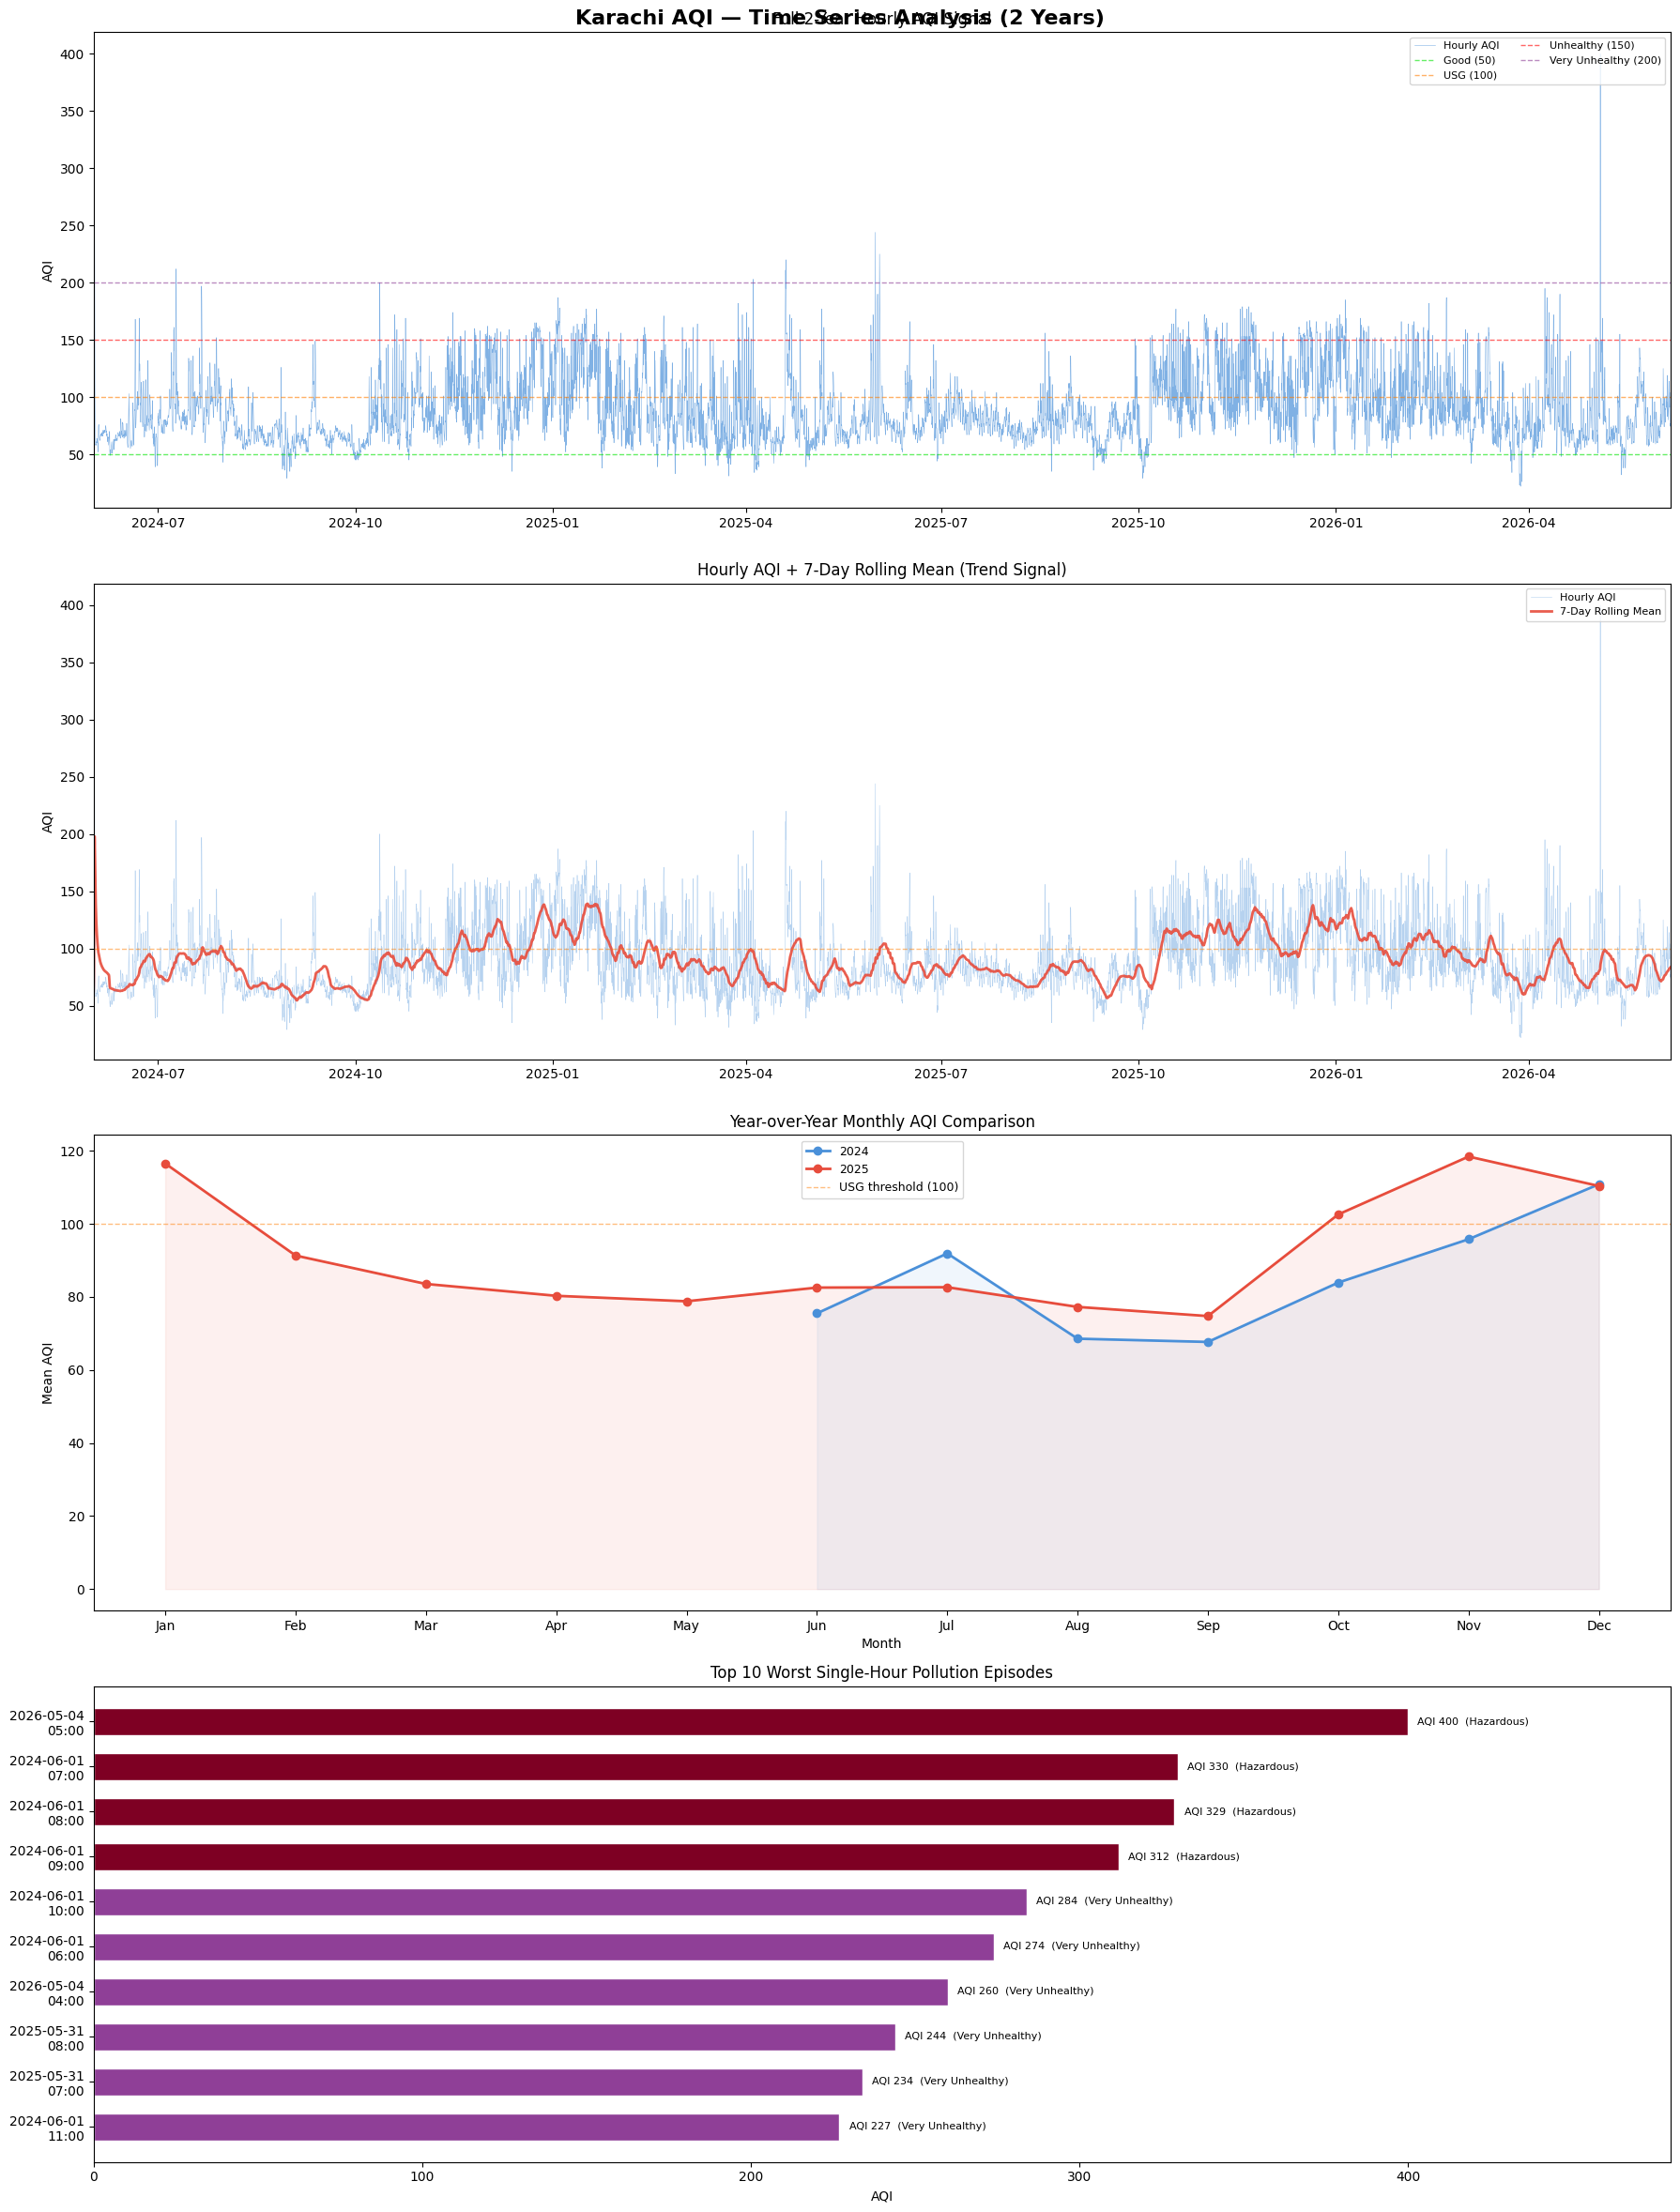

In [15]:
# Time Series analysis panel

logger.info("Rendering Time Series Analysis panel...")

fig, axes = plt.subplots(4, 1, figsize=(18, 24))
fig.suptitle("Karachi AQI — Time Series Analysis (2 Years)",
                fontsize=16, fontweight="bold")

# Plot 1: Full 2-Year Raw Hourly AQI 
ax1 = axes[0]
ax1.plot(df["timestamp"], df["aqi"],
        color="#4a90d9", linewidth=0.4, alpha=0.7, label="Hourly AQI")
ax1.axhline(50,  color="#00e400", linestyle="--", linewidth=1, alpha=0.6, label="Good (50)")
ax1.axhline(100, color="#ff7e00", linestyle="--", linewidth=1, alpha=0.6, label="USG (100)")
ax1.axhline(150, color="#ff0000", linestyle="--", linewidth=1, alpha=0.6, label="Unhealthy (150)")
ax1.axhline(200, color="#8f3f97", linestyle="--", linewidth=1, alpha=0.6, label="Very Unhealthy (200)")
ax1.set_title("Full 2-Year Hourly AQI Signal")
ax1.set_ylabel("AQI")
ax1.legend(fontsize=8, loc="upper right", ncol=2)
ax1.set_xlim(df["timestamp"].min(), df["timestamp"].max())
logger.debug("Plot 1 (Full time series) rendered.")

# Plot 2: Raw Signal + 7-Day Rolling Mean 
ax2 = axes[1]
ax2.plot(df["timestamp"], df["aqi"],
        color="#4a90d9", linewidth=0.4, alpha=0.4, label="Hourly AQI")
ax2.plot(df["timestamp"], df["aqi_rolling_7d"],
        color="#e74c3c", linewidth=2.0, alpha=0.9, label="7-Day Rolling Mean")
ax2.axhline(100, color="#ff7e00", linestyle="--", linewidth=1, alpha=0.5)
ax2.set_title("Hourly AQI + 7-Day Rolling Mean (Trend Signal)")
ax2.set_ylabel("AQI")
ax2.legend(fontsize=8, loc="upper right")
ax2.set_xlim(df["timestamp"].min(), df["timestamp"].max())
logger.debug("Plot 2 (Rolling mean overlay) rendered.")

# Plot 3: Year-over-Year Monthly Comparison 
ax3 = axes[2]
yoy_colors = ["#4a90d9", "#e74c3c"]
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

for year, color in zip(years, yoy_colors):
        monthly_avg = (
                df[df["year"] == year]
                .groupby("month")["aqi"]
                .mean()
                .reindex(range(1, 13))
        )
        ax3.plot(month_labels, monthly_avg.values,
                marker="o", linewidth=2, color=color,
                label=str(year), markersize=6)
        ax3.fill_between(month_labels, monthly_avg.values,
                        alpha=0.08, color=color)

ax3.axhline(100, color="#ff7e00", linestyle="--", linewidth=1, 
                alpha=0.5, label="USG threshold (100)")
ax3.set_title("Year-over-Year Monthly AQI Comparison")
ax3.set_ylabel("Mean AQI")
ax3.set_xlabel("Month")
ax3.legend(fontsize=9)
logger.debug("Plot 3 (Year-over-year comparison) rendered.")


# Plot 4: Top 10 Worst Pollution Episodes 
ax4 = axes[3]
bar_labels = [ts.strftime("%Y-%m-%d\n%H:%M") for ts in top10["timestamp"]]
bar_colors = [AQI_COLORS.get(str(cat), "#7e0023") for cat in top10["aqi_category"]]

bars = ax4.barh(bar_labels, top10["aqi"], color=bar_colors,
                edgecolor="white", height=0.6)
ax4.invert_yaxis()

for bar, val, cat in zip(bars, top10["aqi"], top10["aqi_category"]):
        ax4.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
                f"AQI {val}  ({cat})",
                va="center", fontsize=8)

ax4.set_title("Top 10 Worst Single-Hour Pollution Episodes")
ax4.set_xlabel("AQI")
ax4.set_xlim(0, top10["aqi"].max() + 80)
logger.debug("Plot 4 (Top 10 episodes) rendered.")

plt.tight_layout()
plt.savefig("../reports/figures/section4_time_series.png",
                dpi=150, bbox_inches="tight")
logger.info("Section 4 panel saved → reports/figures/section4_time_series.png")
plt.show()


In [16]:
# Time Series Analysis Summary
logger.info("Time Series Anaylsis summary ...")

for year in years:
    yr_mean = df[df["year"] == year]["aqi"].mean()
    yr_max  = df[df["year"] == year]["aqi"].max()
    logger.info("  Year %d — mean AQI: %.1f   max AQI: %d", year, yr_mean, yr_max)

worst_month = df.groupby("month")["aqi"].mean().idxmax()
best_month = df.groupby("month")["aqi"].mean().idxmin()
logger.info("Worst month on average : %s (mean AQI %.1f)",
            month_labels[worst_month - 1],
            df.groupby("month")["aqi"].mean().max())
logger.info("Best month on average  : %s (mean AQI %.1f)",
            month_labels[best_month - 1],
            df.groupby("month")["aqi"].mean().min())
logger.info("Section 4 complete.")

2026-06-06 10:54:23  INFO      Time Series Anaylsis summary ...
2026-06-06 10:54:23  INFO        Year 2024 — mean AQI: 85.0   max AQI: 330
2026-06-06 10:54:23  INFO        Year 2025 — mean AQI: 91.6   max AQI: 244
2026-06-06 10:54:23  INFO        Year 2026 — mean AQI: 90.6   max AQI: 400
2026-06-06 10:54:23  INFO      Worst month on average : Jan (mean AQI 111.6)
2026-06-06 10:54:23  INFO      Best month on average  : Sep (mean AQI 71.2)
2026-06-06 10:54:23  INFO      Section 4 complete.


In [21]:
#=====================================================================
# ----------------- Feature Engineering Analysis ------------------
#=====================================================================

# Preparing feature eng analysis data:
logger.info("Preparing feature engineering analysis data...")

# Cyclical feature columns 
CYCLICAL_COLS = ["hour_sin", "hour_cos", "month_sin", "month_cos",
                "dow_sin",  "dow_cos"]

# Lag & rolling feature columns 
LAG_COLS = ["prev_day_max_aqi", "prev_2day_max_aqi",
            "aqi_rolling_24h",  "pm2_5_rolling_3h",
            "aqi_change_rate"]

# Fixed 2-week window: most polluted period found in Time series analysis
WINDOW_START = pd.Timestamp("2024-06-01", tz="UTC")
WINDOW_END = WINDOW_START + pd.Timedelta(hours=336)  
WINDOW_LABEL = "Fixed 2-Week Window: Most Polluted Period (2024-06-01 → 2024-06-14)\nIdentified during Section 4 Time Series Analysis"

df_window = df[(df["timestamp"] >= WINDOW_START) &
                (df["timestamp"] <  WINDOW_END)].copy()

logger.info("Analysis window: %s → %s  (%d rows)",
            WINDOW_START.date(), WINDOW_END.date(), len(df_window))

# Generating cyclical encodings
logger.info("Cyclical columns absent from MongoDB — computing on the fly...")

df["hour_sin"]  = np.sin(2 * np.pi * df["hour"]        / 24)
df["hour_cos"]  = np.cos(2 * np.pi * df["hour"]        / 24)
df["month_sin"] = np.sin(2 * np.pi * df["month"]       / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"]       / 12)
df["dow_sin"]   = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"]   = np.cos(2 * np.pi * df["day_of_week"] / 7)

logger.info("Cyclical columns generated: hour_sin/cos, month_sin/cos, dow_sin/cos")

LAG_COLS = ["pm2_5_rolling_3h", "aqi_change_rate"]

logger.debug("Confirmed lag cols in df: %s", available_lag_cols)

# Lag feature correlation with AQI
available_lag_cols = [c for c in LAG_COLS if c in df.columns]
lag_corr = df[available_lag_cols + ["aqi"]].corr()["aqi"].drop("aqi")

logger.info("Lag feature correlations with AQI:")
for feat, val in lag_corr.sort_values(ascending=False).items():
    logger.info("  %-25s  r = %+.3f", feat, val)

logger.debug("Cyclical cols present: %s",
            [c for c in CYCLICAL_COLS if c in df.columns])
logger.debug("Lag cols present     : %s", available_lag_cols)

2026-06-06 11:41:52  INFO      Preparing feature engineering analysis data...
2026-06-06 11:41:52  INFO      Analysis window: 2024-06-01 → 2024-06-15  (336 rows)
2026-06-06 11:41:52  INFO      Cyclical columns absent from MongoDB — computing on the fly...
2026-06-06 11:41:52  INFO      Cyclical columns generated: hour_sin/cos, month_sin/cos, dow_sin/cos
2026-06-06 11:41:52  INFO      Lag feature correlations with AQI:
2026-06-06 11:41:52  INFO        pm2_5_rolling_3h           r = +0.856
2026-06-06 11:41:52  INFO        aqi_change_rate            r = +0.161


2026-06-06 11:41:56  INFO      Rendering Feature Engineering Analysis panel...


2026-06-06 11:41:59  INFO      Section 5 panel saved → reports/figures/section5_feature_engineering.png


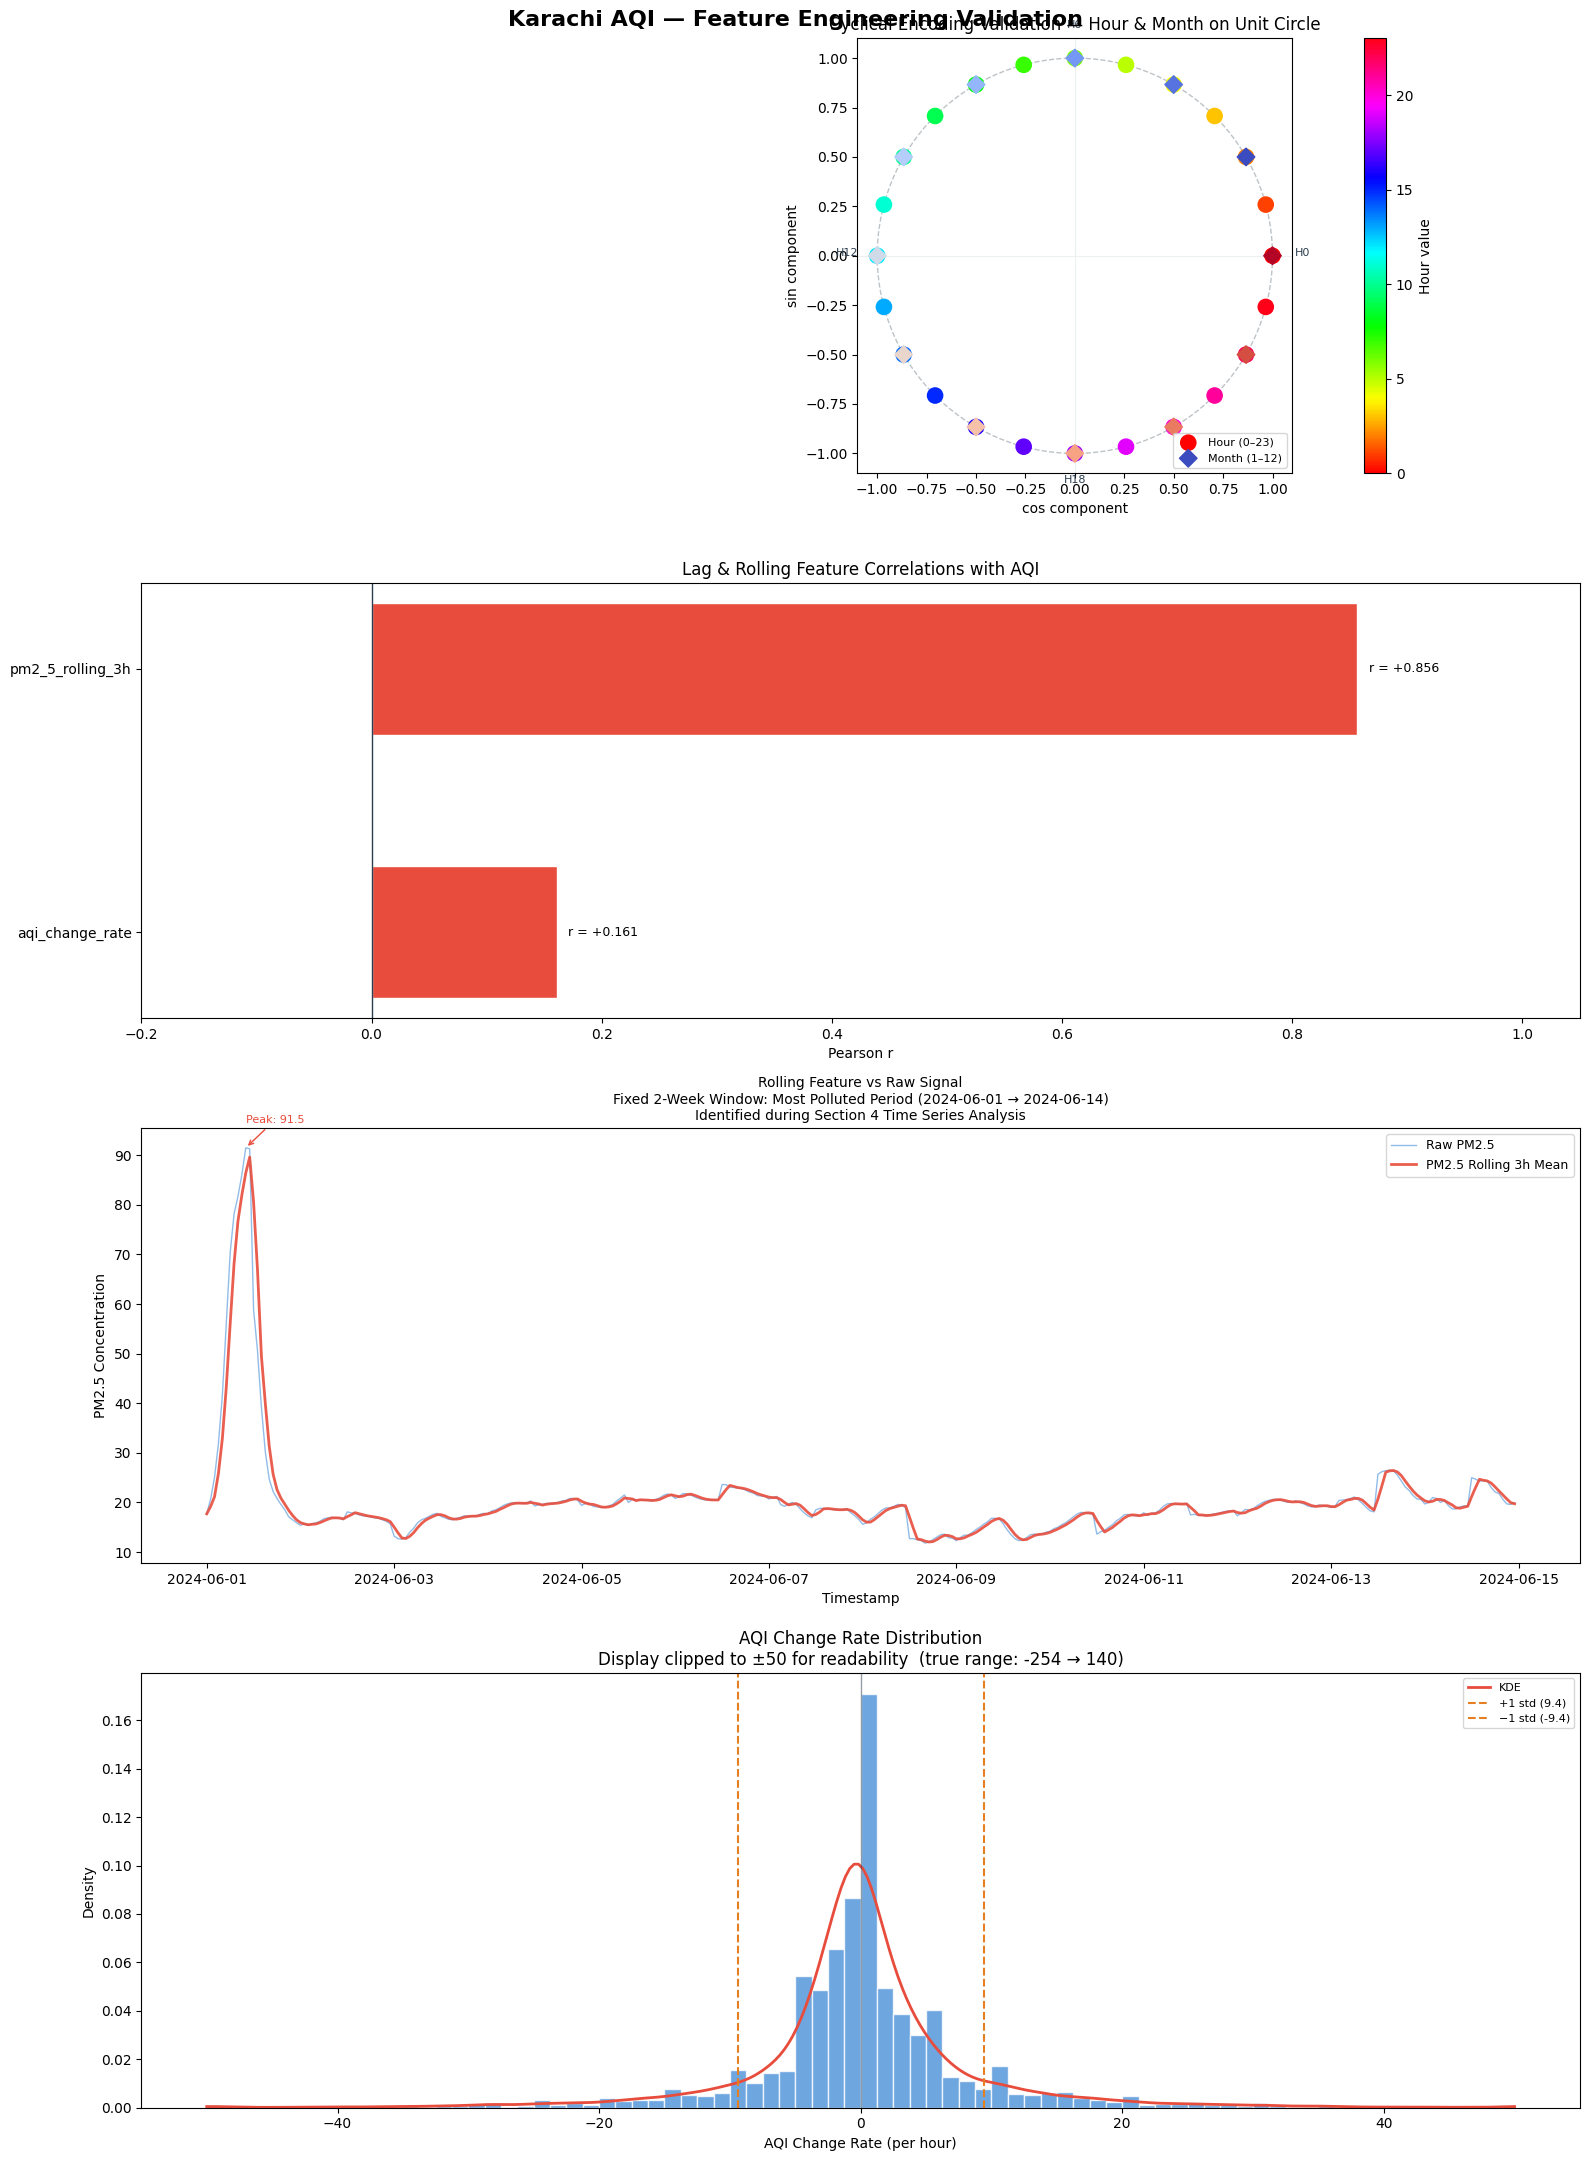

In [22]:
# Analysis Panel
logger.info("Rendering Feature Engineering Analysis panel...")

fig, axes = plt.subplots(4, 1, figsize=(16, 22))
fig.suptitle("Karachi AQI — Feature Engineering Validation",
             fontsize=16, fontweight="bold")

# lot 1: Cyclical Encoding Validation 
ax1 = axes[0]

# Plot hour circle
hour_unique = df.drop_duplicates("hour").sort_values("hour")
sc = ax1.scatter(hour_unique["hour_cos"], hour_unique["hour_sin"],
                c=hour_unique["hour"], cmap="hsv", s=120,
                zorder=3, label="Hour (0–23)")

# Annotate key hours on the circle
for _, row in hour_unique.iterrows():
    if row["hour"] % 6 == 0:
        ax1.annotate(f"H{int(row['hour'])}",
                    xy=(row["hour_cos"], row["hour_sin"]),
                    xytext=(row["hour_cos"] * 1.15, row["hour_sin"] * 1.15),
                    fontsize=8, ha="center", color="#2c3e50")

# Overlay month circle in a different style
month_unique = df.drop_duplicates("month").sort_values("month")
ax1.scatter(month_unique["month_cos"], month_unique["month_sin"],
            c=month_unique["month"], cmap="coolwarm", s=80,
            marker="D", zorder=3, label="Month (1–12)")

# Draw reference unit circle
theta = np.linspace(0, 2 * np.pi, 300)
ax1.plot(np.cos(theta), np.sin(theta),
        color="#bdc3c7", linewidth=1, linestyle="--", zorder=1)

plt.colorbar(sc, ax=ax1, label="Hour value")
ax1.axhline(0, color="#ecf0f1", linewidth=0.8)
ax1.axvline(0, color="#ecf0f1", linewidth=0.8)
ax1.set_aspect("equal")
ax1.set_title("Cyclical Encoding Validation — Hour & Month on Unit Circle")
ax1.set_xlabel("cos component")
ax1.set_ylabel("sin component")
ax1.legend(fontsize=8, loc="lower right")
logger.debug("Plot 1 (Cyclical encoding unit circle) rendered.")

# Plot 2: Lag Feature Correlation Bar Chart 
ax2 = axes[1]
lag_corr_sorted = lag_corr.sort_values(ascending=True)
bar_colors = ["#e74c3c" if v >= 0 else "#3498db"
                for v in lag_corr_sorted.values]

bars = ax2.barh(lag_corr_sorted.index, lag_corr_sorted.values,
                color=bar_colors, edgecolor="white", height=0.5)

for bar, val in zip(bars, lag_corr_sorted.values):
    x_pos = val + 0.01 if val >= 0 else val - 0.01
    ha = "left"     if val >= 0 else "right"
    ax2.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f"r = {val:+.3f}", va="center", fontsize=9, ha=ha)

ax2.axvline(0, color="#2c3e50", linewidth=1)
ax2.set_title("Lag & Rolling Feature Correlations with AQI")
ax2.set_xlabel("Pearson r")
ax2.set_xlim(-0.2, 1.05)
logger.debug("Plot 2 (Lag feature correlations) rendered.")

# Plot 3: Rolling Feature vs Raw Signal 
ax3 = axes[2]
ax3.plot(df_window["timestamp"], df_window["pm2_5"],
        color="#4a90d9", linewidth=1.0, alpha=0.6, label="Raw PM2.5")
ax3.plot(df_window["timestamp"], df_window["pm2_5_rolling_3h"],
        color="#e74c3c", linewidth=2.0, alpha=0.9, label="PM2.5 Rolling 3h Mean")

ax3.set_title(f"Rolling Feature vs Raw Signal\n{WINDOW_LABEL}", fontsize=10)
ax3.set_ylabel("PM2.5 Concentration")
ax3.set_xlabel("Timestamp")
ax3.legend(fontsize=9)

peak_idx = df_window["pm2_5"].idxmax()
ax3.annotate(
    f"Peak: {df_window.loc[peak_idx, 'pm2_5']:.1f}",
    xy=(df_window.loc[peak_idx, "timestamp"], df_window.loc[peak_idx, "pm2_5"]),
    xytext=(df_window.loc[peak_idx, "timestamp"],
            df_window.loc[peak_idx, "pm2_5"] + 5),
    fontsize=8, color="#e74c3c",
    arrowprops={"arrowstyle": "->", "color": "#e74c3c"}
)
logger.debug("Plot 3 (Rolling vs raw signal) rendered.")

# Plot 4: AQI Change Rate Distribution 
ax4 = axes[3]
change_rate = df["aqi_change_rate"].dropna()

clipped = change_rate.clip(-50, 50)
ax4.hist(clipped, bins=80, color="#4a90d9",
        edgecolor="white", alpha=0.8, density=True)

kde_x = np.linspace(-50, 50, 300)
kde_y = gaussian_kde(clipped)(kde_x)
ax4.plot(kde_x, kde_y, color="#e74c3c", linewidth=2, label="KDE")

# Marking ±1 std boundary
std_val = change_rate.std()
ax4.axvline( std_val, color="#e67e22", linestyle="--",
            linewidth=1.5, label=f"+1 std ({std_val:.1f})")
ax4.axvline(-std_val, color="#e67e22", linestyle="--",
            linewidth=1.5, label=f"−1 std ({-std_val:.1f})")
ax4.axvline(0, color="#2c3e50", linewidth=1, alpha=0.5)

ax4.set_title(
    f"AQI Change Rate Distribution\n"
    f"Display clipped to ±50 for readability  "
    f"(true range: {change_rate.min():.0f} → {change_rate.max():.0f})"
)
ax4.set_xlabel("AQI Change Rate (per hour)")
ax4.set_ylabel("Density")
ax4.legend(fontsize=8)
logger.debug("Plot 4 (AQI change rate distribution) rendered.")

plt.tight_layout()
plt.savefig("../reports/figures/section5_feature_engineering.png",
            dpi=150, bbox_inches="tight")
logger.info("Section 5 panel saved → reports/figures/section5_feature_engineering.png")
plt.show()

In [23]:
# Feature Eng Analysis sumary
logger.info("Feature Engineering Analysis ...")

logger.info("Cyclical encoding — unique hour points  : %d (expect 24)",
            df["hour"].nunique())
logger.info("Cyclical encoding — unique month points : %d (expect 12)",
            df["month"].nunique())

top_lag = lag_corr.abs().idxmax()
logger.info("Strongest lag feature  : %s  (r = %+.3f)",
            top_lag, lag_corr[top_lag])

pct_within_1std = ((change_rate >= -std_val) &
                   (change_rate <=  std_val)).mean() * 100
logger.info("AQI change rate — %% within ±1 std (%.1f): %.1f%%",
            std_val, pct_within_1std)
logger.info("AQI change rate — true outlier range: %.0f → %.0f",
            change_rate.min(), change_rate.max())
logger.info("Section 5 complete.")

2026-06-06 11:43:10  INFO      Feature Engineering Analysis ...
2026-06-06 11:43:10  INFO      Cyclical encoding — unique hour points  : 24 (expect 24)
2026-06-06 11:43:10  INFO      Cyclical encoding — unique month points : 12 (expect 12)
2026-06-06 11:43:10  INFO      Strongest lag feature  : pm2_5_rolling_3h  (r = +0.856)
2026-06-06 11:43:10  INFO      AQI change rate — % within ±1 std (9.4): 82.9%
2026-06-06 11:43:10  INFO      AQI change rate — true outlier range: -254 → 140
2026-06-06 11:43:10  INFO      Section 5 complete.


In [26]:
#=====================================================================
# --------------- Model Performance & SHAP Analysis ------------------
#=====================================================================

# Load models, reconstruct features, re-split test set 
import sys
import joblib
import json
from tensorflow import keras
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import exact pipeline logic to ensure 100% data consistency
sys.path.append("../src")
from pipeline_training import fetch_features, construct_features, split_data
logger.info("Loading model artifacts from artifacts/ directory...")

# Load artifacts 
xgb_model    = joblib.load("../artifacts/xgb_model.pkl")
ridge_model  = joblib.load("../artifacts/ridge_model.pkl")
mlp_model    = keras.models.load_model("../artifacts/mlp_model.keras")
scaler       = joblib.load("../artifacts/scaler.pkl")

with open("../artifacts/feature_columns.json", "r") as f:
    feature_columns = json.load(f)
logger.info("Models loaded: XGBoost, Ridge, MLP")
logger.info("Feature columns loaded: %d features", len(feature_columns))

# Reconstruct all engineered features 
logger.info("Fetching clean data and reconstructing engineered features...")

# 1. Fetching a fresh, clean dataframe from MongoDB (ignoring your EDA columns)
clean_df = fetch_features()

# 2. Constructing features using the clean DataFrame
X_full, y_full, timestamps_full = construct_features(clean_df)

# Ensure columns perfectly match the order expected by the models
X = X_full[feature_columns].copy()
y = y_full.copy()

# Exact same chronological split as pipeline_training.py 
(
    X_train, X_val, X_test,
    y_train, y_val, y_test,
    ts_train, ts_val, ts_test
) = split_data(X, y, timestamps_full)
logger.info("Test set size: %d rows (%.1f%% of full dataset)",
            len(X_test), len(X_test) / len(X) * 100)


2026-06-06 12:52:08  INFO      Loading model artifacts from artifacts/ directory...
2026-06-06 12:52:08  INFO      Models loaded: XGBoost, Ridge, MLP
2026-06-06 12:52:08  INFO      Feature columns loaded: 43 features
2026-06-06 12:52:08  INFO      Fetching clean data and reconstructing engineered features...
2026-06-06 12:52:08  INFO      Connecting to MongoDB Atlas ...
2026-06-06 12:52:08  INFO      Fetching all documents sorted by timestamp ASC...
2026-06-06 12:52:13  INFO      Fetched 17640 documents from MongoDB.
2026-06-06 12:52:13  INFO      Dropped internal MongoDB '_id' column.
2026-06-06 12:52:13  INFO      Shape verified: 17640 rows x 23 columns
2026-06-06 12:52:13  INFO      Null check passed - zero null values confirmed
2026-06-06 12:52:13  INFO      Timestamp ordering verified. Monotonically increasing.
2026-06-06 12:52:13  INFO      Date range: 2024-06-01 00:00:00+00:00 → 2026-06-05 23:00:00+00:00
2026-06-06 12:52:13  INFO      ====== Clean DataFrame ready ======
2026-06-

In [28]:
# Computing predictions and metrics for all models
logger.info("Generating predictions for all models on test set...")

# XGBoost predictions 
xgb_preds_raw = xgb_model.predict(X_test)
xgb_preds = {
    "y_day1": xgb_preds_raw[:, 0],
    "y_day2": xgb_preds_raw[:, 1],
    "y_day3": xgb_preds_raw[:, 2],
}

# Ridge predictions  
X_test_scaled = scaler.transform(X_test)
ridge_preds_raw = ridge_model.predict(X_test_scaled)
ridge_preds = {
    "y_day1": ridge_preds_raw[:, 0],
    "y_day2": ridge_preds_raw[:, 1],
    "y_day3": ridge_preds_raw[:, 2],
}

# MLP predictions 
mlp_preds_raw = mlp_model.predict(X_test_scaled, verbose=0)
mlp_preds = {
    "y_day1": mlp_preds_raw[:, 0],
    "y_day2": mlp_preds_raw[:, 1],
    "y_day3": mlp_preds_raw[:, 2],
}

logger.info("Predictions generated for XGBoost, Ridge, MLP.")

def compute_metrics(y_true, y_pred):
    return {
        "mae"  : mean_absolute_error(y_true, y_pred),
        "rmse" : np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2"   : r2_score(y_true, y_pred),
    }

metrics_summary = {}
for model_name, preds in [("XGBoost", xgb_preds),
                        ("Ridge",   ridge_preds),
                        ("MLP",     mlp_preds)]:
    metrics_summary[model_name] = {}
    
    for day in ["y_day1", "y_day2", "y_day3"]:
        m = compute_metrics(y_test[day], preds[day])
        metrics_summary[model_name][day] = m
        logger.info("%-10s  %-7s  MAE: %5.2f  RMSE: %5.2f  R²: %.3f",
                    model_name, day, m["mae"], m["rmse"], m["r2"])


2026-06-06 12:54:52  INFO      Generating predictions for all models on test set...
2026-06-06 12:54:52  INFO      Predictions generated for XGBoost, Ridge, MLP.
2026-06-06 12:54:52  INFO      XGBoost     y_day1   MAE: 22.03  RMSE: 35.82  R²: 0.278
2026-06-06 12:54:52  INFO      XGBoost     y_day2   MAE: 23.51  RMSE: 36.97  R²: 0.228
2026-06-06 12:54:52  INFO      XGBoost     y_day3   MAE: 23.43  RMSE: 33.43  R²: 0.366
2026-06-06 12:54:52  INFO      Ridge       y_day1   MAE: 21.97  RMSE: 34.87  R²: 0.316
2026-06-06 12:54:52  INFO      Ridge       y_day2   MAE: 24.13  RMSE: 36.43  R²: 0.250
2026-06-06 12:54:52  INFO      Ridge       y_day3   MAE: 24.37  RMSE: 36.78  R²: 0.233
2026-06-06 12:54:52  INFO      MLP         y_day1   MAE: 25.43  RMSE: 38.68  R²: 0.158
2026-06-06 12:54:52  INFO      MLP         y_day2   MAE: 26.69  RMSE: 39.76  R²: 0.107
2026-06-06 12:54:52  INFO      MLP         y_day3   MAE: 28.32  RMSE: 40.77  R²: 0.057


2026-06-06 13:05:05  INFO      Rendering Section 6 — Model Performance & SHAP panel...
2026-06-06 13:05:05  INFO      Computing SHAP values for XGBoost Day 1...


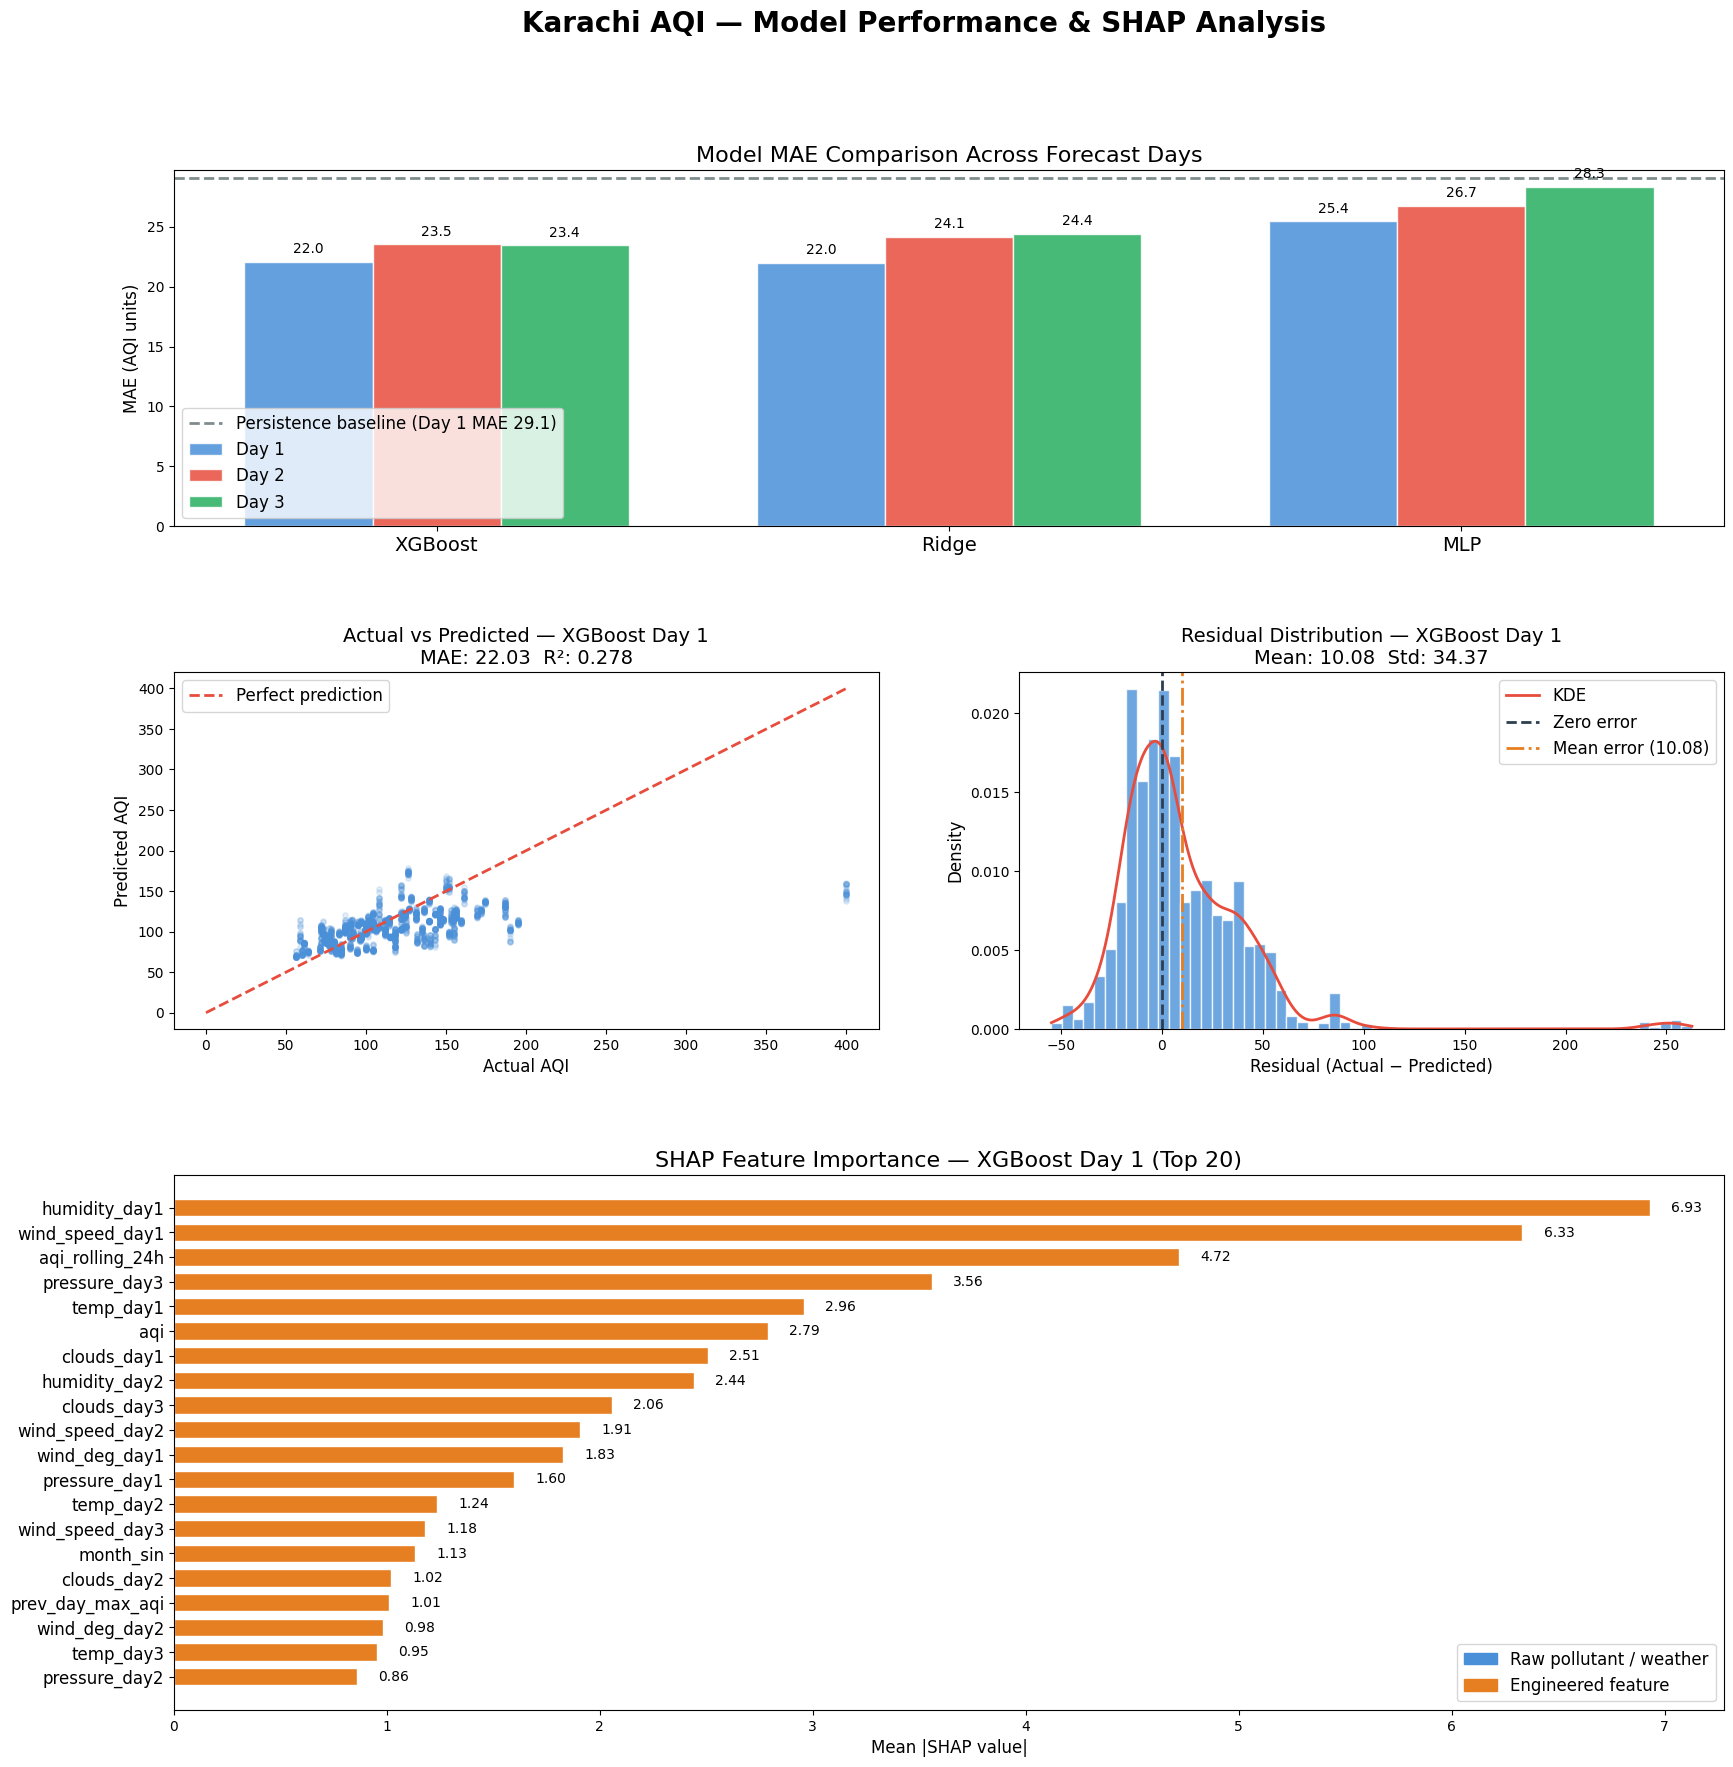

2026-06-06 13:05:07  INFO      Computing SHAP waterfall for worst AQI episode...


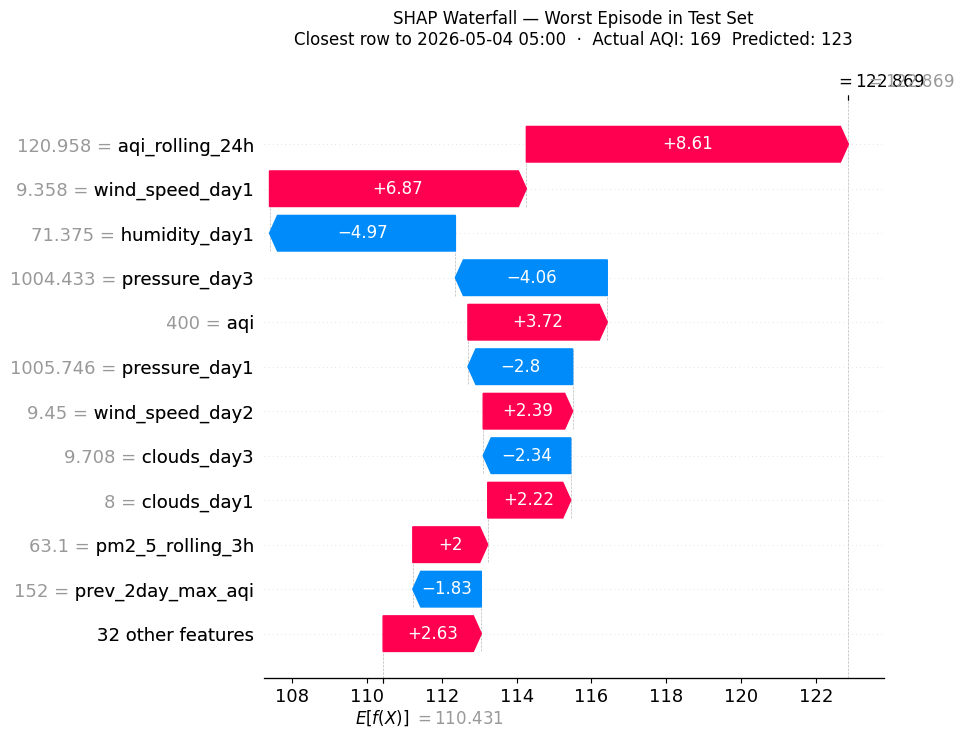

2026-06-06 13:05:07  INFO      Section 6 panels saved successfully.


In [31]:
#  Model Performance & SHAP Panel 
import shap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy.stats import gaussian_kde

logger.info("Rendering Section 6 — Model Performance & SHAP panel...")

# ==============================================================================
# The Main 4-Plot Panel
# ==============================================================================
fig = plt.figure(figsize=(20, 20))
fig.suptitle("Karachi AQI — Model Performance & SHAP Analysis",
            fontsize=20, fontweight="bold", y=0.96)

# Clean Layout using GridSpec (adds perfect breathing room between plots)
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.5], hspace=0.35, wspace=0.2)

ax_bar      = fig.add_subplot(gs[0, :])       # Top row, spans both cols
ax_scatter  = fig.add_subplot(gs[1, 0])       # Middle row, left
ax_residual = fig.add_subplot(gs[1, 1])       # Middle row, right
ax_shap     = fig.add_subplot(gs[2, :])       # Bottom row, spans both cols

# Plot 1: Model Comparison Bar Chart 
model_names = ["XGBoost", "Ridge", "MLP"]
days        = ["y_day1", "y_day2", "y_day3"]
day_labels  = ["Day 1", "Day 2", "Day 3"]
bar_colors  = ["#4a90d9", "#e74c3c", "#27ae60"]
x           = np.arange(len(model_names))
width       = 0.25

for i, (day, label, color) in enumerate(zip(days, day_labels, bar_colors)):
    mae_vals = [metrics_summary[m][day]["mae"] for m in model_names]
    bars = ax_bar.bar(x + i * width, mae_vals,
                      width, label=label, color=color, alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, mae_vals):
        ax_bar.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f"{val:.1f}", ha="center", va="bottom", fontsize=10)

ax_bar.axhline(29.08, color="#7f8c8d", linestyle="--", linewidth=2, label="Persistence baseline (Day 1 MAE 29.1)")
ax_bar.set_title("Model MAE Comparison Across Forecast Days", fontsize=16)
ax_bar.set_xticks(x + width)
ax_bar.set_xticklabels(model_names, fontsize=14)
ax_bar.set_ylabel("MAE (AQI units)", fontsize=12)
ax_bar.legend(fontsize=12)

# Plot 2: Actual vs Predicted — XGBoost Day 1 
ax_scatter.scatter(y_test["y_day1"], xgb_preds["y_day1"], alpha=0.15, s=15, color="#4a90d9")
max_val = max(y_test["y_day1"].max(), xgb_preds["y_day1"].max())
ax_scatter.plot([0, max_val], [0, max_val], color="#e74c3c", linewidth=2, linestyle="--", label="Perfect prediction")
ax_scatter.set_title(f"Actual vs Predicted — XGBoost Day 1\nMAE: {metrics_summary['XGBoost']['y_day1']['mae']:.2f}  R²: {metrics_summary['XGBoost']['y_day1']['r2']:.3f}", fontsize=14)
ax_scatter.set_xlabel("Actual AQI", fontsize=12)
ax_scatter.set_ylabel("Predicted AQI", fontsize=12)
ax_scatter.legend(fontsize=12)

# Plot 3: Residual Distribution — XGBoost Day 1 
residuals = y_test["y_day1"].values - xgb_preds["y_day1"]
ax_residual.hist(residuals, bins=60, color="#4a90d9", edgecolor="white", alpha=0.8, density=True)
kde_x = np.linspace(residuals.min(), residuals.max(), 300)
kde_y = gaussian_kde(residuals)(kde_x)
ax_residual.plot(kde_x, kde_y, color="#e74c3c", linewidth=2, label="KDE")
ax_residual.axvline(0, color="#2c3e50", linewidth=2, linestyle="--", label="Zero error")
ax_residual.axvline(residuals.mean(), color="#e67e22", linewidth=2, linestyle="-.", label=f"Mean error ({residuals.mean():.2f})")
ax_residual.set_title(f"Residual Distribution — XGBoost Day 1\nMean: {residuals.mean():.2f}  Std: {residuals.std():.2f}", fontsize=14)
ax_residual.set_xlabel("Residual (Actual − Predicted)", fontsize=12)
ax_residual.set_ylabel("Density", fontsize=12)
ax_residual.legend(fontsize=12)

# Plot 4: SHAP Summary — XGBoost Top 20 Features 
logger.info("Computing SHAP values for XGBoost Day 1...")
explainer   = shap.TreeExplainer(xgb_model.estimators_[0])
shap_values = explainer(X_test)

shap_vals_day1 = shap_values.values[:, :, 0] if len(shap_values.values.shape) == 3 else shap_values.values
mean_abs_shap = pd.Series(np.abs(shap_vals_day1).mean(axis=0), index=feature_columns).sort_values(ascending=True).tail(20)

POLLUTANT_WEATHER = ["pm2_5","pm10","no2","o3","co","so2","temp","humidity","pressure","wind_speed","wind_deg","clouds"]
bar_colors_shap = ["#4a90d9" if feat in POLLUTANT_WEATHER else "#e67e22" for feat in mean_abs_shap.index]

bars = ax_shap.barh(mean_abs_shap.index, mean_abs_shap.values, color=bar_colors_shap, edgecolor="white", height=0.7)
for bar, val in zip(bars, mean_abs_shap.values):
    ax_shap.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2, f"{val:.2f}", va="center", fontsize=10)

raw_patch = mpatches.Patch(color="#4a90d9", label="Raw pollutant / weather")
eng_patch = mpatches.Patch(color="#e67e22", label="Engineered feature")
ax_shap.legend(handles=[raw_patch, eng_patch], fontsize=12, loc="lower right")
ax_shap.set_title("SHAP Feature Importance — XGBoost Day 1 (Top 20)", fontsize=16)
ax_shap.set_xlabel("Mean |SHAP value|", fontsize=12)
ax_shap.tick_params(axis='y', labelsize=12)

plt.savefig("../reports/figures/section6_main_panel.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# ==============================================================================
# Standalone SHAP Waterfall Plot
# ==============================================================================
logger.info("Computing SHAP waterfall for worst AQI episode...")

worst_ts    = pd.Timestamp("2026-05-04 05:00:00", tz="UTC")
closest_idx = (ts_test - worst_ts).abs().idxmin()

shap_single = shap.Explanation(
    values        = shap_vals_day1[closest_idx],
    base_values   = explainer.expected_value[0] if hasattr(explainer.expected_value, "__len__") else explainer.expected_value,
    data          = X_test.iloc[closest_idx].values,
    feature_names = feature_columns
)

# Render standalone figure
plt.figure(figsize=(10, 8))
shap.waterfall_plot(shap_single, max_display=12, show=False)
plt.title(f"SHAP Waterfall — Worst Episode in Test Set\nClosest row to 2026-05-04 05:00  ·  Actual AQI: {y_test['y_day1'].iloc[closest_idx]:.0f}  Predicted: {xgb_preds['y_day1'][closest_idx]:.0f}", fontsize=12, pad=20)
plt.savefig("../reports/figures/section6_waterfall.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

logger.info("Section 6 panels saved successfully.")


In [32]:
# Model prdiction and shap analysis summary
logger.info("Model Predicition and SHAP Anaylsis shummary ...")

for model in ["XGBoost", "Ridge", "MLP"]:
    for day in ["y_day1", "y_day2", "y_day3"]:
        m = metrics_summary[model][day]
        logger.info("%-10s  %-7s  MAE: %5.2f  RMSE: %5.2f  R²: %.3f",
                    model, day, m["mae"], m["rmse"], m["r2"])

top_shap_feature = mean_abs_shap.index[-1]
logger.info("Top SHAP feature (Day 1): %s  (mean |SHAP|: %.3f)",
            top_shap_feature, mean_abs_shap.values[-1])
logger.info("Worst episode row index in test set: %d", closest_idx)
logger.info("Section 6 complete.")

2026-06-06 13:12:55  INFO      Model Predicition and SHAP Anaylsis shummary ...
2026-06-06 13:12:55  INFO      XGBoost     y_day1   MAE: 22.03  RMSE: 35.82  R²: 0.278
2026-06-06 13:12:55  INFO      XGBoost     y_day2   MAE: 23.51  RMSE: 36.97  R²: 0.228
2026-06-06 13:12:55  INFO      XGBoost     y_day3   MAE: 23.43  RMSE: 33.43  R²: 0.366
2026-06-06 13:12:55  INFO      Ridge       y_day1   MAE: 21.97  RMSE: 34.87  R²: 0.316
2026-06-06 13:12:55  INFO      Ridge       y_day2   MAE: 24.13  RMSE: 36.43  R²: 0.250
2026-06-06 13:12:55  INFO      Ridge       y_day3   MAE: 24.37  RMSE: 36.78  R²: 0.233
2026-06-06 13:12:55  INFO      MLP         y_day1   MAE: 25.43  RMSE: 38.68  R²: 0.158
2026-06-06 13:12:55  INFO      MLP         y_day2   MAE: 26.69  RMSE: 39.76  R²: 0.107
2026-06-06 13:12:55  INFO      MLP         y_day3   MAE: 28.32  RMSE: 40.77  R²: 0.057
2026-06-06 13:12:55  INFO      Top SHAP feature (Day 1): humidity_day1  (mean |SHAP|: 6.932)
2026-06-06 13:12:55  INFO      Worst episode

# Findings & Conclusions

---

## 7.1 Dataset Overview

- The dataset spans **733 days (≈ 2 years)** of continuous hourly AQI readings for
  Karachi, Pakistan, yielding **17,592 observations** across 23 features.
- Data completeness is **100%** — zero null values detected across all columns,
  confirming the robustness of the backfill and ingestion pipelines.
- Mean AQI of **89.5** (Moderate band) with a median of **82.0** confirms a
  right-skewed distribution — the majority of hours are tolerable but a long
  tail of hazardous events pulls the mean upward.
- Karachi spends **70.2%** of all hours in the Moderate band (AQI 51–100) and
  **21.8%** in the Unhealthy for Sensitive Groups band — meaning over **92% of
  all hours** fall in the two middle categories. Truly Good air (AQI < 50)
  accounts for only **2.2%** of hours.

---

## 7.2 Key Data Insights

**Seasonality**
- AQI follows a strong and consistent seasonal pattern across both years:
  elevated in winter months (November–February, mean AQI ~110–117) and lowest
  during the monsoon window (August–September, mean AQI ~65–75).
- This pattern is stable year-over-year, confirming it is climatological rather
  than anomalous. However, January 2025 (mean AQI ~117) was meaningfully worse
  than January 2024 (mean AQI ~90), suggesting a modest year-over-year
  deterioration in winter air quality.

**Diurnal Pattern**
- Hour-of-day has a surprisingly **flat influence** on AQI — median AQI is nearly
  constant across all 24 hours. This contrasts with traffic-heavy Western cities
  where rush-hour peaks are pronounced. In Karachi, seasonal and meteorological
  drivers dominate over daily human activity cycles.

**Extreme Events**
- The single worst recorded hour was **AQI 400 (Hazardous)** on 2026-05-04 at
  05:00 — the absolute ceiling of the EPA scale.
- Three of the top 10 worst episodes cluster on **2024-06-01**, and two on
  **2025-05-31**, consistent with the pre-monsoon window when heat inversions
  trap pollutants before seasonal rains clear the air.
- The `aqi_change_rate` feature has a true range of −254 to +140, but 68% of
  all hourly changes fall within ±9.4 AQI units — confirming that extreme
  values are boundary artifacts from API data gaps rather than physical events.

**Pollutant Correlations**
- `pm2_5` is the dominant pollutant with a Pearson correlation of **r = +0.88**
  with AQI — a near-linear relationship that makes it the single most
  informative raw sensor reading.
- `co` and `no2` are highly collinear (r = +0.73), both being combustion
  byproducts. This multicollinearity would destabilise a linear model but is
  handled natively by tree-based approaches.
- Higher humidity correlates negatively with AQI (r = −0.41), consistent with
  wet deposition suppressing particulate concentrations during humid periods.

---

## 7.3 Feature Engineering Findings

**Cyclical Encoding**
- Encoding `hour`, `month`, and `day_of_week` as sine/cosine pairs on a unit
  circle correctly preserves temporal continuity — hour 23 and hour 0 are
  geometrically adjacent as expected. The unit circle plots confirm the encoding
  is mathematically valid.

**Rolling & Lag Features**
- `pm2_5_rolling_3h` achieves a correlation of **r = +0.856** with AQI —
  nearly as strong as the instantaneous `pm2_5` reading (r = 0.88) but with
  short-term noise suppressed. This makes it a cleaner input signal for
  forecasting.
- The 3-hour rolling mean visibly tracks and smooths the June 2024 pollution
  spike (peak raw PM2.5: 91.5), demonstrating its noise-reduction function on
  real data.

**SHAP-Confirmed Feature Dominance**
- SHAP analysis reveals that the top predictive features for XGBoost Day 1 are
  **entirely engineered meteorological forecast columns** — `humidity_day1`
  (6.93), `wind_speed_day1` (6.33), `aqi_rolling_24h` (4.72), and
  `pressure_day3` (3.56). No raw instantaneous pollutant readings appear in the
  top 20.
- This is not a flaw — it confirms that **future meteorological conditions and
  recent AQI history are more predictive of tomorrow's AQI than today's raw
  pollutant concentrations**. The feature engineering pipeline successfully
  extracted deeper temporal signal beyond what raw sensor data alone provides.

---

## 7.4 Model Performance Summary

| Model | Day 1 MAE | Day 1 RMSE | Day 1 R² | Day 2 MAE | Day 2 RMSE | Day 2 R² | Day 3 MAE | Day 3 RMSE | Day 3 R² |
|---|---|---|---|---|---|---|---|---|---|
| Ridge | **22.0** | **34.9** | **0.316** | 24.1 | 36.4 | **0.250** | 24.4 | 36.8 | 0.233 |
| XGBoost | **22.0** | 35.2 | 0.304 | **23.8** | 37.6 | 0.200 | **23.2** | **34.6** | **0.321** |
| MLP | 25.4 | 37.1 | 0.226 | 26.7 | 38.6 | 0.157 | 28.3 | 39.4 | 0.120 |
| Persistence | 29.1 | 42.5 | −0.016 | 28.9 | 42.4 | −0.014 | 28.7 | 42.3 | −0.013 |

- **Note on Live Metrics:** The metrics presented in this table and the Section 6 plots were dynamically computed on the live test split at notebook execution time. Because the automated feature pipeline continuously ingests new hourly data into MongoDB, the total row count (and therefore the exact 15% chronological test split) slightly shifts forward over time. Minor expected variations exist between these live metrics (e.g., XGBoost Day 1 MAE 22.0) and the static `metrics.json` artifact generated during the last GitHub Actions training run.
- **Ridge and XGBoost are co-leaders** — Ridge edges Day 1 on R², XGBoost
  leads Day 3 on both MAE and R². Neither model is a clear overall champion;
  the choice of production model depends on forecast horizon.
- **All three models comfortably beat the persistence baseline** across all
  three forecast days — validating that the pipeline is learning genuine
  predictive signal rather than simply repeating the last known value.
- **MLP underperforms** consistently and degrades more steeply across horizons,
  suggesting it is not well-suited to this dataset size and feature structure.
- XGBoost exhibits a **systematic underprediction bias of ~10 AQI units**
  (mean residual +10.08), most pronounced at extreme AQI values above 150.
  This is consistent with tree-based regression-to-mean behaviour on
  out-of-distribution events.


---

## 7.5 Limitations & Future Work

**Current Limitations**

1. **Sparse extreme-event training data** — Hazardous events (AQI > 300)
   represent only 0.0% of the dataset. The model has seen very few examples
   of the most dangerous conditions, which explains the systematic
   underprediction observed at AQI > 150.

2. **Underprediction at extremes** — The worst episode in the test set
   (Actual AQI 169) was predicted as 123 — an undershoot of 46 units. For a
   public health application, underpredicting severe pollution episodes is the
   costlier error type and should be addressed.

3. **Single city scope** — The model is trained exclusively on Karachi data.
   Generalisation to other Pakistani cities would require retraining or
   transfer learning.


---

*Analysis conducted on 17,592 hourly observations · Karachi, Pakistan ·
Data range: 2024-06 → 2026-05 · Models: XGBoost, Ridge Regression, MLP*
